<a href="https://colab.research.google.com/github/BKover99/epitome_tools_star_protocols/blob/main/cell_annotation_protocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preliminary information

This Jupyter notebook accompanies the STAR Protocols manuscript (Kövér, Goddard, Dogan, Andoniadou; 2026). While the protocol shows RNA and ATAC analysis simulatenously, here we structured the notebook such that first the RNA workflow is shown, which is then followed by the ATAC workflow.



For any questions, please open an issue in https://github.com/BKover99/epitome_tools_star_protocols

## How to run this notebook:
- (**A**) You can use Google Colab - for slower execution the free instance should suffice, but for faster execution, you might need the paid subscription, which allows higher RAM (memory) as well. In this case, proceed to the next step of installing the required packages.

- (**B**) You can download the notebook, and run it locally. In that case we suggest setting up a conda environment. For instructions on setting up a conda environment and running the notebook locally, we've put a section at the very bottom of the notebook, so it doesn't interfere with running the code in Google Colab.

## Install packages defined as requirements

In [ ]:
%%writefile requirements.txt
scanpy==1.12.3
igraph==1.0.0
leidenalg==0.12.0
epitome_tools==1.0.8
scikit-misc==0.5.2
polars==1.43.2
anndata==0.13.2
snapatac2==2.10.0
scikit-learn==1.6.1
numpy<2.1

Writing requirements.txt


If on Google Colab, the following code should be run instead:

In [ ]:
from tqdm.auto import tqdm
import subprocess

with open("requirements.txt") as f:
    packages = [line.strip() for line in f if line.strip()]

for pkg in tqdm(packages, desc="Installing packages"):
    subprocess.run(["pip", "install", "--upgrade", pkg], check=True)

Installing packages:   0%|          | 0/10 [00:00<?, ?it/s]

## Mount Google Drive, in case you would like to save files as checkpoints or long term storage

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#suppress all warnings
import warnings
warnings.filterwarnings('ignore')

## Finding run accessions for datasets


NCBI: SRX30501235 and SRX30501234

As shown on https://www.ncbi.nlm.nih.gov/sra, these datasets consist of the following runs:

SRX30501235: SRR35421867

SRX30501234: SRR35421868

## Downloading fastq files from the SRA for each corresponding run

While we will not download these files here into a google colab, the reader can do this in their own environment (locally or HPC) by executing the following code



```
install sudo apt install sra-toolkit

!for id in SRR35421867 SRR35421868; do prefetch --max-size 500G $id && fastq-dump --outdir /target_dir/ --gzip --split-files $id; done
```



Beyond this point, we assume that the reader has run Cell Ranger or is comfortable with moving forward with the files pre-processed by us. At this point, ensure that the required files are present in the environment, either through downloading them in the next code block, or uploading them to the right folder (e.g. onto Google Colab) for access.

# Downloading datasets from Zenodo - Approx. 20 mins



1.   Multiome ATAC data - Cell Ranger ATAC output files


*   Specifically, we need the **fragments.tsv.gz** file


2.   Multiome RNA data - Cell Ranger output files
*   Specifically, we need the **raw_feature_bc_matrix.h5** file




In [ ]:
import os
# Below are the zenodo IDs corresponding to each dataset
files = {
    "SRX30501234_atac_outs.zip": "04f995e0254d21f96bd814628a8875ef",
    "SRX30501235_rna_outs.zip":  "81ac5586108bd9fcccc7920fd68b19d8"
}

base = "https://zenodo.org/records/20749243/files/{}?download=1"

# # Setup directory - to be adapted if working locally
os.makedirs("/content/zenodo/", exist_ok=True)

for name in files:
    url = base.format(name)
    #download
    !wget -c -O "/content/zenodo/{name}" "{url}"
    #unzip
    !unzip -q "/content/zenodo/{name}" -d /content/zenodo/

--2026-08-25 06:47:47--  https://zenodo.org/records/20749243/files/SRX30501234_atac_outs.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.43.153, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1816363915 (1.7G) [application/octet-stream]
Saving to: ‘/content/zenodo/SRX30501234_atac_outs.zip’

/content/zenodo/SRX 100%[===================>]   1.69G  2.66MB/s    in 7m 44s  

2026-08-25 06:55:32 (3.74 MB/s) - ‘/content/zenodo/SRX30501234_atac_outs.zip’ saved [1816363915/1816363915]

--2026-08-25 06:55:55--  https://zenodo.org/records/20749243/files/SRX30501235_rna_outs.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.52.235, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 194503354 (185M) [application/octet-stream]
Saving to: ‘/content/ze

# **Protocol starts here** - Restart kernel before proceeding!

In [ ]:
#import packages
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import median_abs_deviation as mad

In [ ]:
#make figures directory if doesn't exist
if not os.path.exists("figures"):
  os.makedirs("figures")

### Load dataset - Approx. 1 min


In [ ]:
adata_mm = sc.read_10x_h5("/content/zenodo/SRX30501235_rna_outs/raw_feature_bc_matrix.h5")

/usr/local/lib/python3.13/dist-packages/scanpy/readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


### Filtering dataset

In [ ]:
def qc1(adata,min_genes=800, min_counts=1000):
    """QC function, filtering cells and genes,
    #adding mitochondrial and ribosomal flags to adata.var
    #and calculating general QC metrics"""

    sc.pp.filter_cells(adata, min_genes = min_genes)
    sc.pp.filter_cells(adata, min_counts = min_counts)

    mt_tag="mt-"
    ribo_tag=("Rps","Rpl")
    malat_tag = "Malat1"

    adata.var["mt"] = adata.var_names.str.startswith(mt_tag)
    adata.var["ribo"] = adata.var_names.str.startswith(ribo_tag)
    adata.var["malat"] = adata.var_names.str.startswith(malat_tag)

    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "malat"], inplace=True, percent_top=[20], log1p=True)
    return adata

def mad_outlier(adata, metric, nmads, upper_only = False, value = False):
    """function to calculate median absolute deviation cut-offs"""
    if value and upper_only:
      upper_val = np.median(adata.obs[metric]) + nmads * mad(adata.obs[metric])
      return [upper_val,0]
    elif value and not upper_only:
      upper_val = np.median(adata.obs[metric]) + nmads * mad(adata.obs[metric])
      lower_val = np.median(adata.obs[metric]) - nmads * mad(adata.obs[metric])
      return [upper_val,lower_val]
    else:
      M = adata.obs[metric]

      if not upper_only:
          return (M < np.median(M) - nmads * mad(M)) | (M > np.median(M) + nmads * mad(M))

    return (M > np.median(M) + nmads * mad(M))

def violinplot(ax, adata, col, vals):
    """function to generate violin plots with red cut-off lines"""
    values = adata.obs[col].values
    sns.violinplot(y=values, ax=ax)
    for v in vals:
        ax.axhline(v, color='red')
    ax.set_title(col)
    ax.set_ylabel('')

def qc2(adata):
    """second QC function, filtering cells based on multiple criteria, using
    median absolute deviation cut-offs as shown on the violin plots"""
    mt_val = mad_outlier(adata, 'pct_counts_mt', 5, upper_only=True, value=True)
    ribo_val = mad_outlier(adata, 'pct_counts_ribo', 5, upper_only=True, value=True)
    malat_val = mad_outlier(adata, 'pct_counts_malat', 5, upper_only=True, value=True)
    log1p_n_genes_val = mad_outlier(adata, 'log1p_n_genes_by_counts', 4, upper_only=False, value=True)
    log1p_total_val = mad_outlier(adata, 'log1p_total_counts', 4, upper_only=False, value=True)
    top_genes_val = mad_outlier(adata, 'pct_counts_in_top_20_genes', 5, upper_only=True, value=True)

    # Generate panel of violin plots
    fig, axs = plt.subplots(2, 3, figsize=(8, 5.5))
    axs = axs.flatten()

    violinplot(axs[0], adata, 'pct_counts_mt', mt_val + [25])
    violinplot(axs[1], adata, 'pct_counts_ribo', ribo_val + [30])
    violinplot(axs[2], adata, 'pct_counts_malat', malat_val)
    violinplot(axs[3], adata, 'log1p_n_genes_by_counts', log1p_n_genes_val)
    violinplot(axs[4], adata, 'log1p_total_counts', log1p_total_val)
    violinplot(axs[5], adata, 'pct_counts_in_top_20_genes', top_genes_val)

    plt.tight_layout()
    plt.savefig(f"figures/vlnplot.png", dpi=800)
    plt.savefig(f"figures/vlnplot.svg", format="svg", bbox_inches="tight")



    #create boolean filter to remove cells
    bool_vector = mad_outlier(adata, 'pct_counts_mt', 5, upper_only=True) + \
                  mad_outlier(adata, 'pct_counts_ribo', 5, upper_only=True) + \
                  mad_outlier(adata, 'pct_counts_malat', 5, upper_only=True) + \
                  mad_outlier(adata, 'log1p_n_genes_by_counts', 4) + \
                  mad_outlier(adata, 'log1p_total_counts', 4) + \
                  mad_outlier(adata, 'pct_counts_in_top_20_genes', 5, upper_only=True)

    adata = adata[~bool_vector]

    adata = adata[adata.obs.pct_counts_mt < 25]
    adata = adata[adata.obs.pct_counts_ribo < 30]


    adata.uns['cells_removed'] = sum(bool_vector)

    return adata, fig


### Running the filtering - Approx. 1 min

Initial dataset: 637,237 droplets × 33,696 genes


/usr/local/lib/python3.13/dist-packages/scanpy/preprocessing/_simple.py:164: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata._inplace_subset_obs(cell_subset)
/usr/local/lib/python3.13/dist-packages/scanpy/preprocessing/_simple.py:164: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata._inplace_subset_obs(cell_subset)


After QC1:       4,083 cells × 33,696 genes


/tmp/ipykernel_31923/3725928495.py:87: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['cells_removed'] = sum(bool_vector)
/usr/lib/python3.13/contextlib.py:141: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  return next(self.gen)
/usr/lib/python3.13/contextlib.py:148: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  next(self.gen)


After QC2:       3,539 cells × 33,696 genes


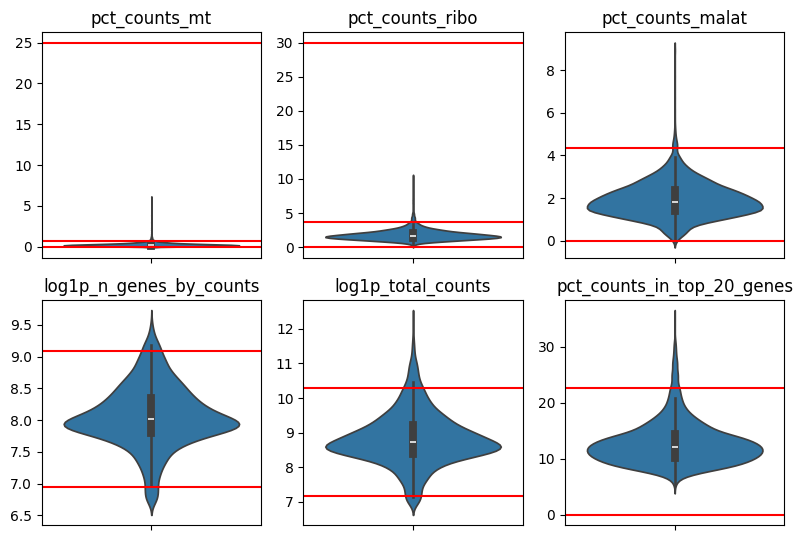

In [ ]:
print(f"Initial dataset: {adata_mm.shape[0]:,} droplets × {adata_mm.shape[1]:,} genes")

adata_mm= qc1(adata_mm)
print(f"After QC1:       {adata_mm.shape[0]:,} cells × {adata_mm.shape[1]:,} genes")

adata_mm, violinplots = qc2(adata_mm) # Figure 1A
print(f"After QC2:       {adata_mm.shape[0]:,} cells × {adata_mm.shape[1]:,} genes")

### Normalisation, PCA, UMAP standard workflow - Approx. 1 min

/usr/local/lib/python3.13/dist-packages/scanpy/preprocessing/_highly_variable_genes.py:174: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata_agg = AnnData(
/usr/local/lib/python3.13/dist-packages/scanpy/preprocessing/_highly_variable_genes.py:191: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  aggregated_mean_var = AnnData(
/tmp/ipykernel_31923/1676840295.py:11: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(adata, n_comps=42, use_highly_variable=True, svd_solver="arpack")


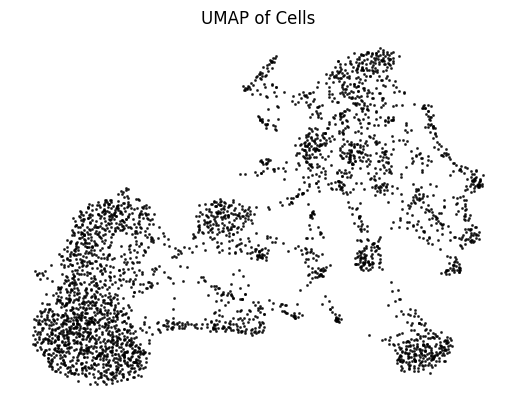

In [ ]:
def to_umap(adata):
  """function to generate UMAP for normalized dataset"""
  # Highly variable genes
  sc.pp.highly_variable_genes(adata, flavor="seurat_v3",n_top_genes=2000,subset=False)

  # Normalize and log1p
  sc.pp.normalize_total(adata_mm, target_sum=1e4)
  sc.pp.log1p(adata_mm)

  # PCA using only HVGs
  sc.pp.pca(adata, n_comps=42, use_highly_variable=True, svd_solver="arpack")

  # Compute neighborhood graph
  sc.pp.neighbors(adata, n_neighbors=15, n_pcs=42,random_state=42)

  # UMAP
  sc.tl.umap(adata, random_state=42)
  ax = sc.pl.umap(adata, size=5, alpha=0.7, frameon=False, title="UMAP of Cells", color=None, show=False)
  ax.collections[0].set_color("black")
  plt.savefig(f"figures/umap.png", dpi=800)
  plt.show()

adata_mm.layers["raw_counts"] = adata_mm.X.copy()

to_umap(adata_mm) # Figure 1B

### Running epitome_tools for doublet detection - Approx. 5-10 seconds

In [ ]:
from epitome_tools.workflow import doublet_workflow
import time

start_mm = time.time()

doublet_workflow(
  adata_mm,
  active_assay="multi_rna", #can take values "multi_rna", "sc", "sn"
  modality="rna", #can take values "rna", "atac"
  in_place=True,
  species="mouse")

end_mm = time.time()
print(f"Time taken for dataset: {end_mm - start_mm} seconds")

Percentage of features present in adata: 98.00%
At least 70% of the features are present in the adata object.
The dataset has passed the compatibility check.
Time taken for dataset: 9.070593357086182 seconds


### Inspecting the obs table to understand doublet output

In [ ]:
#show all cols
pd.set_option('display.max_columns', None)

In [ ]:
adata_mm.obs

,n_genes,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_malat,log1p_total_counts_malat,pct_counts_malat,pct_counts_kept,init_predicted_doublet_epitome,thresholded_doublet_epitome,doublet_score_epitome,final_doublet_label,doublet_uncertainty
AAACAGCCAAGGATTA-1,5453,14451.0,5453,8.604105,14451.0,9.578588,10.206906,50.0,3.931826,0.345997,352.0,5.866468,2.435817,295.0,5.690360,2.041381,0.300394,doublet,True,0.805519,doublet,0.194481
AAACAGCCAGCATGAG-1,2628,4906.0,2628,7.874359,4906.0,8.498418,15.246637,22.0,3.135494,0.448431,107.0,4.682131,2.181003,70.0,4.262680,1.426824,0.334896,real,False,0.031388,real,0.031388
AAACAGCCATAAGTTC-1,4818,11412.0,4818,8.480322,11412.0,9.342508,7.974062,68.0,4.234107,0.595864,214.0,5.370638,1.875219,95.0,4.564348,0.832457,0.350771,doublet,True,0.980100,doublet,0.019900
AAACAGCCATATAACC-1,4028,9570.0,4028,8.301273,9570.0,9.166493,10.052247,3.0,1.386294,0.031348,92.0,4.532599,0.961338,136.0,4.919981,1.421108,0.285266,doublet,False,0.618066,real,0.381934
AAACATGCAGATTCAT-1,5042,13107.0,5042,8.525756,13107.0,9.480978,8.148318,14.0,2.708050,0.106813,243.0,5.497168,1.853971,224.0,5.416101,1.709010,0.326619,real,False,0.403322,real,0.403322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTACTAAAC-1,5812,18329.0,5812,8.667852,18329.0,9.816295,11.304490,21.0,3.091043,0.114573,222.0,5.407172,1.211195,396.0,5.983936,2.160511,0.373779,doublet,True,0.941900,doublet,0.058100
TTTGTTGGTCGACTCC-1,2727,5241.0,2727,7.911324,5241.0,8.564459,12.593017,4.0,1.609438,0.076321,69.0,4.248495,1.316543,115.0,4.753590,2.194238,0.333143,real,False,0.336420,real,0.336420
TTTGTTGGTTAATGCG-1,8047,26619.0,8047,8.993179,26619.0,10.189418,7.517187,63.0,4.158883,0.236673,646.0,6.472346,2.426838,462.0,6.137727,1.735602,0.328525,doublet,True,0.960996,doublet,0.039004
TTTGTTGGTTCCGCAC-1,2559,4961.0,2559,7.847763,4961.0,8.509564,15.440435,3.0,1.386294,0.060472,81.0,4.406719,1.632735,90.0,4.510859,1.814150,0.345696,real,False,0.190988,real,0.190988


/tmp/ipykernel_31923/197518406.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


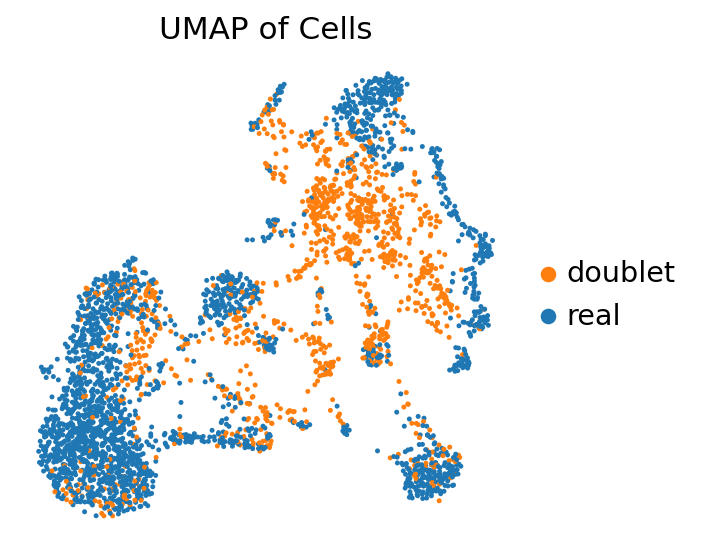

In [ ]:
def plot_cells(adata, column,palette=sc.pl.palettes.default_20,name="",sort=True):
  """plotting function wrapping the standard scanpy umap function"""
  sc.pl.umap(
        adata,
        color=column,
        palette=palette,
        size=20,
        alpha=1,
        sort_order=sort,
        frameon=False,
        title="UMAP of Cells",
        save=f"_{column}_{name}.png",
        show=True)


doublet_palette = {
    "real": "#1f77b4",
    "doublet": "#ff7f0e"
}

# Set high-resolution saving
sc.settings.figdir = "./figures"
sc.set_figure_params(dpi_save=600)

plot_cells(adata_mm, "final_doublet_label", palette=doublet_palette, name="doublets_present") # Figure 3

### Below we can explore the values assigned by epitome_tools to each cell in adata.obs. Specifically, in the columns:
 'init_predicted_doublet_epitome', 'thresholded_doublet_epitome', 'doublet_score_epitome', 'final_doublet_label', 'doublet_uncertainty'

In [ ]:
adata_mm.obs

,n_genes,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_malat,log1p_total_counts_malat,pct_counts_malat,pct_counts_kept,init_predicted_doublet_epitome,thresholded_doublet_epitome,doublet_score_epitome,final_doublet_label,doublet_uncertainty
AAACAGCCAAGGATTA-1,5453,14451.0,5453,8.604105,14451.0,9.578588,10.206906,50.0,3.931826,0.345997,352.0,5.866468,2.435817,295.0,5.690360,2.041381,0.300394,doublet,True,0.805519,doublet,0.194481
AAACAGCCAGCATGAG-1,2628,4906.0,2628,7.874359,4906.0,8.498418,15.246637,22.0,3.135494,0.448431,107.0,4.682131,2.181003,70.0,4.262680,1.426824,0.334896,real,False,0.031388,real,0.031388
AAACAGCCATAAGTTC-1,4818,11412.0,4818,8.480322,11412.0,9.342508,7.974062,68.0,4.234107,0.595864,214.0,5.370638,1.875219,95.0,4.564348,0.832457,0.350771,doublet,True,0.980100,doublet,0.019900
AAACAGCCATATAACC-1,4028,9570.0,4028,8.301273,9570.0,9.166493,10.052247,3.0,1.386294,0.031348,92.0,4.532599,0.961338,136.0,4.919981,1.421108,0.285266,doublet,False,0.618066,real,0.381934
AAACATGCAGATTCAT-1,5042,13107.0,5042,8.525756,13107.0,9.480978,8.148318,14.0,2.708050,0.106813,243.0,5.497168,1.853971,224.0,5.416101,1.709010,0.326619,real,False,0.403322,real,0.403322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTACTAAAC-1,5812,18329.0,5812,8.667852,18329.0,9.816295,11.304490,21.0,3.091043,0.114573,222.0,5.407172,1.211195,396.0,5.983936,2.160511,0.373779,doublet,True,0.941900,doublet,0.058100
TTTGTTGGTCGACTCC-1,2727,5241.0,2727,7.911324,5241.0,8.564459,12.593017,4.0,1.609438,0.076321,69.0,4.248495,1.316543,115.0,4.753590,2.194238,0.333143,real,False,0.336420,real,0.336420
TTTGTTGGTTAATGCG-1,8047,26619.0,8047,8.993179,26619.0,10.189418,7.517187,63.0,4.158883,0.236673,646.0,6.472346,2.426838,462.0,6.137727,1.735602,0.328525,doublet,True,0.960996,doublet,0.039004
TTTGTTGGTTCCGCAC-1,2559,4961.0,2559,7.847763,4961.0,8.509564,15.440435,3.0,1.386294,0.060472,81.0,4.406719,1.632735,90.0,4.510859,1.814150,0.345696,real,False,0.190988,real,0.190988


### Removing doublets

/usr/local/lib/python3.13/dist-packages/scanpy/plotting/_utils.py:511: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/tmp/ipykernel_31923/197518406.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


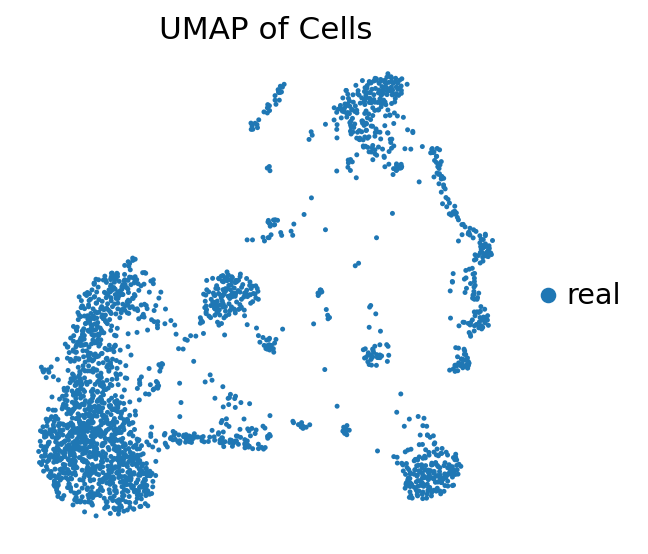

AnnData object with n_obs × n_vars = 2388 × 33696
    obs: 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_malat', 'log1p_total_counts_malat', 'pct_counts_malat', 'pct_counts_kept', 'init_predicted_doublet_epitome', 'thresholded_doublet_epitome', 'doublet_score_epitome', 'final_doublet_label', 'doublet_uncertainty'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'malat', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cells_removed', 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'final_doublet_label_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivi

In [ ]:
#subsetting for "real" cells as opposed to "doublet" cells
adata_mm = adata_mm[adata_mm.obs.final_doublet_label == "real"]
plot_cells(adata_mm, "final_doublet_label", palette={"real": "#1f77b4","doublet": "#ff7f0e"}, name="doublets_removed") # Figure 3
adata_mm

### Running epitome_tools for cell typing - Approx. 5-10 seconds

In [ ]:
from epitome_tools.workflow import cell_type_workflow, doublet_workflow
import time

start_mm = time.time()

cell_type_workflow(
  adata_mm,
  active_assay="multi_rna",
  modality="rna",
  in_place=True,
  species="mouse",
  smoothing=True)

end_mm = time.time()
print(f"Time taken for dataset: {end_mm - start_mm} seconds")

Percentage of features present in adata: 98.04%
At least 70% of the features are present in the adata object.
The dataset has passed the compatibility check.
Time taken for dataset: 9.99648141860962 seconds


### Below we can explore the values assigned by epitome_tools to each cell in adata.obs. Specifically, in the columns:
predicted_cell_type 	predicted_cell_type_proba 	cell_type_uncertainty 	proba_Corticotrophs 	proba_Endothelial_cells 	proba_Erythrocytes 	proba_Gonadotrophs 	proba_Immune_cells 	proba_Lactotrophs 	proba_Melanotrophs 	proba_Mesenchymal_cells 	proba_Pituicytes 	proba_Somatotrophs 	proba_Stem_cells 	proba_Thyrotrophs 	cell_type_final

In [ ]:
adata_mm.obs

,n_genes,n_counts,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_malat,log1p_total_counts_malat,pct_counts_malat,pct_counts_kept,init_predicted_doublet_epitome,thresholded_doublet_epitome,doublet_score_epitome,final_doublet_label,doublet_uncertainty,predicted_cell_type,predicted_cell_type_proba,cell_type_uncertainty,proba_Corticotrophs,proba_Endothelial_cells,proba_Erythrocytes,proba_Gonadotrophs,proba_Immune_cells,proba_Lactotrophs,proba_Melanotrophs,proba_Mesenchymal_cells,proba_Pituicytes,proba_Somatotrophs,proba_Stem_cells,proba_Thyrotrophs,cell_type_final
AAACAGCCAGCATGAG-1,2628,4906.0,2628,7.874359,4906.0,8.498418,15.246637,22.0,3.135494,0.448431,107.0,4.682131,2.181003,70.0,4.262680,1.426824,0.334896,real,False,0.031388,real,0.031388,Somatotrophs,0.942559,0.057441,0.004509,0.000563,0.000339,0.003077,0.000890,0.002672,0.007832,0.001468,0.002105,0.942559,0.000696,0.033292,Somatotrophs
AAACAGCCATATAACC-1,4028,9570.0,4028,8.301273,9570.0,9.166493,10.052247,3.0,1.386294,0.031348,92.0,4.532599,0.961338,136.0,4.919981,1.421108,0.285266,doublet,False,0.618066,real,0.381934,Somatotrophs,0.950643,0.049357,0.004482,0.000553,0.000373,0.004792,0.001152,0.007121,0.001390,0.002182,0.003081,0.950643,0.000953,0.023277,Somatotrophs
AAACATGCAGATTCAT-1,5042,13107.0,5042,8.525756,13107.0,9.480978,8.148318,14.0,2.708050,0.106813,243.0,5.497168,1.853971,224.0,5.416101,1.709010,0.326619,real,False,0.403322,real,0.403322,Stem_cells,0.996246,0.003754,0.000204,0.000075,0.000039,0.000270,0.000076,0.000445,0.000599,0.000224,0.000170,0.001240,0.996246,0.000413,Stem_cells
AAACCGAAGTAATCCA-1,2940,5452.0,2940,7.986505,5452.0,8.603921,15.590609,20.0,3.044523,0.366838,121.0,4.804021,2.219369,68.0,4.234107,1.247249,0.304109,real,False,0.234442,real,0.234442,Somatotrophs,0.990039,0.009961,0.000558,0.000209,0.000132,0.001586,0.000434,0.002030,0.000424,0.000769,0.000846,0.990039,0.000247,0.002725,Somatotrophs
AAACCGCGTACCTTAC-1,3923,9184.0,3923,8.274867,9184.0,9.125327,14.503484,34.0,3.555348,0.370209,152.0,5.030438,1.655052,376.0,5.932245,4.094077,0.398737,doublet,False,0.567626,real,0.432374,Thyrotrophs,0.980320,0.019680,0.001711,0.000085,0.000058,0.014028,0.000099,0.001397,0.000586,0.000283,0.000354,0.000933,0.000148,0.980320,Thyrotrophs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGGCAATTGAAG-1,2830,5561.0,2830,7.948385,5561.0,8.623713,13.558712,20.0,3.044523,0.359648,120.0,4.795791,2.157885,119.0,4.787492,2.139903,0.348678,real,False,0.274737,real,0.274737,Somatotrophs,0.962050,0.037950,0.002831,0.000474,0.000281,0.009347,0.001146,0.001261,0.008652,0.000937,0.002358,0.962050,0.000572,0.010091,Somatotrophs
TTTGTGGCAGGGAGCT-1,2331,4193.0,2331,7.754482,4193.0,8.341411,13.784880,4.0,1.609438,0.095397,42.0,3.761200,1.001669,77.0,4.356709,1.836394,0.373003,real,False,0.449695,real,0.449695,Corticotrophs,0.976123,0.023877,0.976123,0.000190,0.000060,0.000681,0.000163,0.000423,0.000391,0.000525,0.001250,0.000974,0.000240,0.018980,Corticotrophs
TTTGTGTTCGGGACTC-1,3508,6453.0,3508,8.163086,6453.0,8.772455,7.190454,27.0,3.332205,0.418410,187.0,5.236442,2.897877,50.0,3.931826,0.774833,0.298311,real,False,0.081482,real,0.081482,Stem_cells,0.993611,0.006389,0.000346,0.000063,0.000046,0.000775,0.000089,0.000494,0.000185,0.000149,0.000201,0.003462,0.993611,0.000578,Stem_cells
TTTGTTGGTCGACTCC-1,2727,5241.0,2727,7.911324,5241.0,8.564459,12.593017,4.0,1.609438,0.076321,69.0,4.248495,1.316543,115.0,4.753590,2.194238,0.333143,real,False,0.336420,real,0.336420,Somatotrophs,0.961596,0.038404,0.006291,0.000743,0.000455,0.005519,0.000889,0.004829,0.001281,0.001804,0.002754,0.961596,0.002747,0.011093,Somatotrophs


/tmp/ipykernel_31923/197518406.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


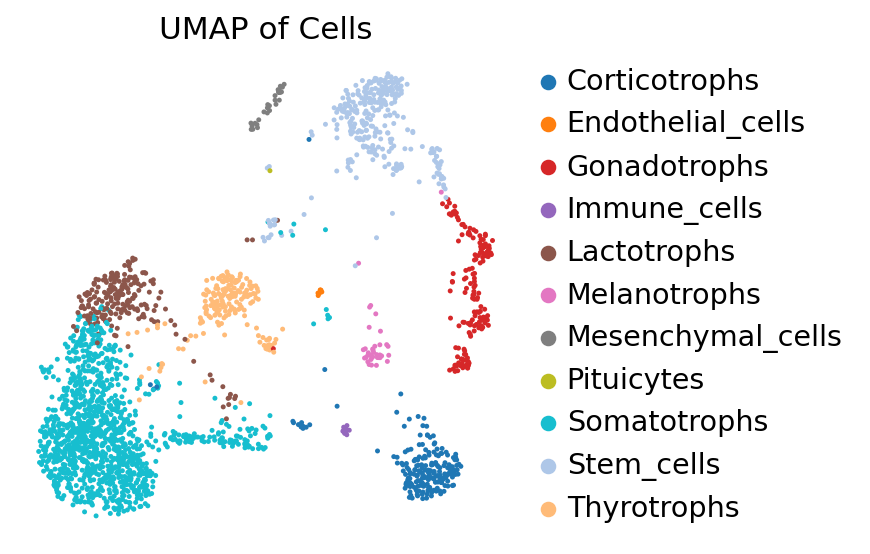

/tmp/ipykernel_31923/197518406.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


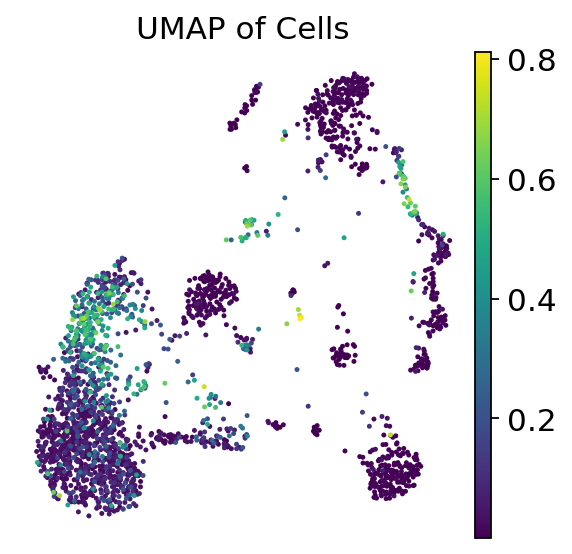

/tmp/ipykernel_31923/197518406.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


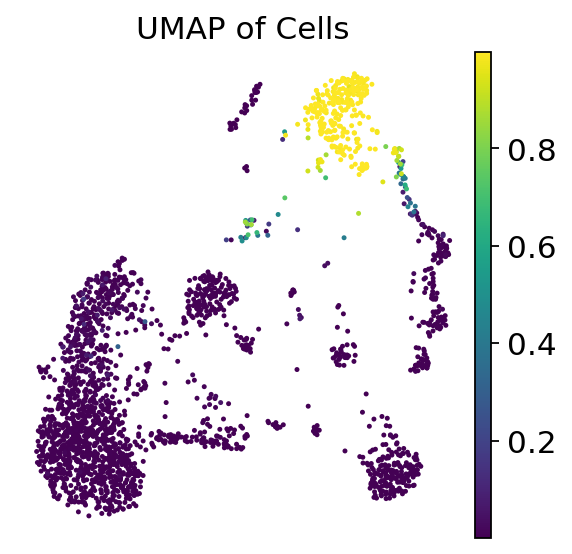

In [ ]:
cell_type_palette = {
        'Corticotrophs': "#1f77b4",
        'Endothelial_cells': "#ff7f0e",
        'Erythrocytes': "#2ca02c",
        'Gonadotrophs': "#d62728",
        'Immune_cells': "#9467bd",
        'Lactotrophs': "#8c564b",
        'Melanotrophs': "#e377c2",
        'Mesenchymal_cells': "#7f7f7f",
        'Pituicytes': "#bcbd22",
        'Somatotrophs': "#17becf",
        'Stem_cells': "#aec7e8",
        'Thyrotrophs': "#ffbb78"
    }

plot_cells(adata_mm,"cell_type_final", palette= cell_type_palette, name="rna") # Figure 4A
plot_cells(adata_mm,"cell_type_uncertainty", name="rna") # Figure 5A
plot_cells(adata_mm,"proba_Stem_cells", name="rna") # Figure 5B

### Calculating Pseudotime values on the Stem cell to Gonadotroph trajectory

/tmp/ipykernel_31923/1524508577.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sc_gonado_subset.obs["sc_gonado_pseudotime"] = (
/tmp/ipykernel_31923/197518406.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


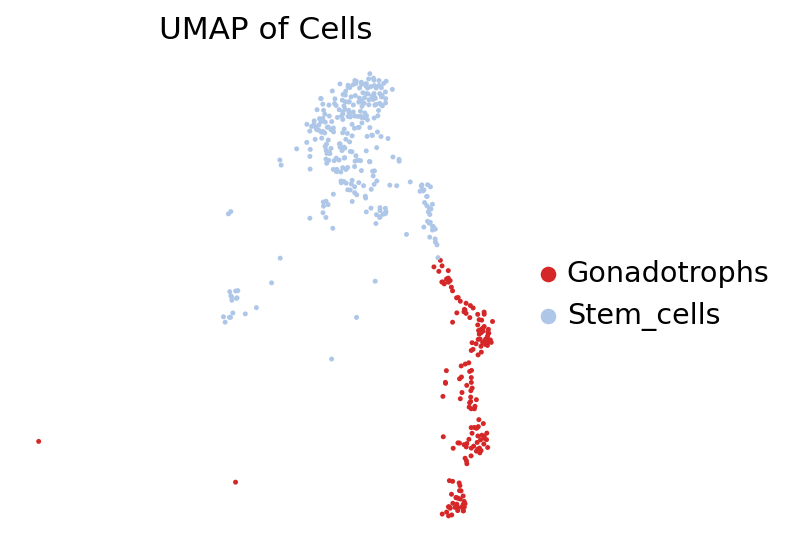

/tmp/ipykernel_31923/197518406.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


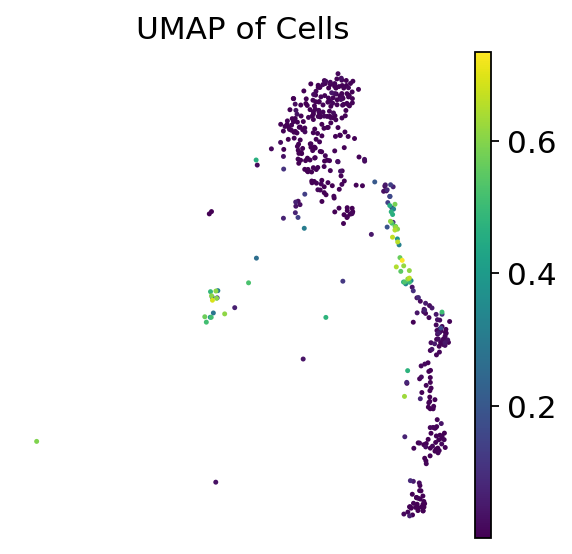

/tmp/ipykernel_31923/197518406.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


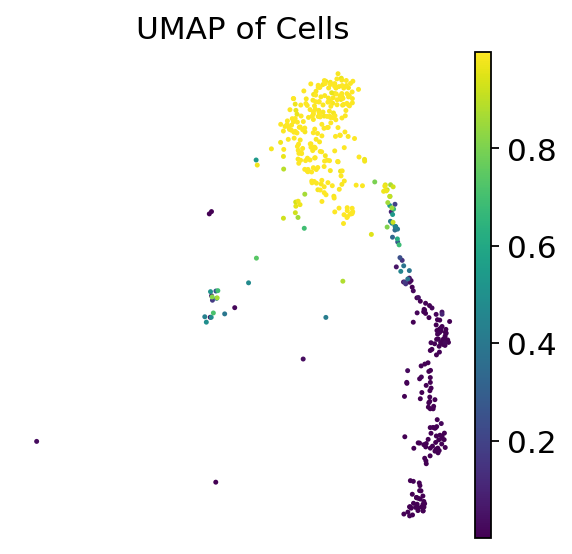

/tmp/ipykernel_31923/197518406.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


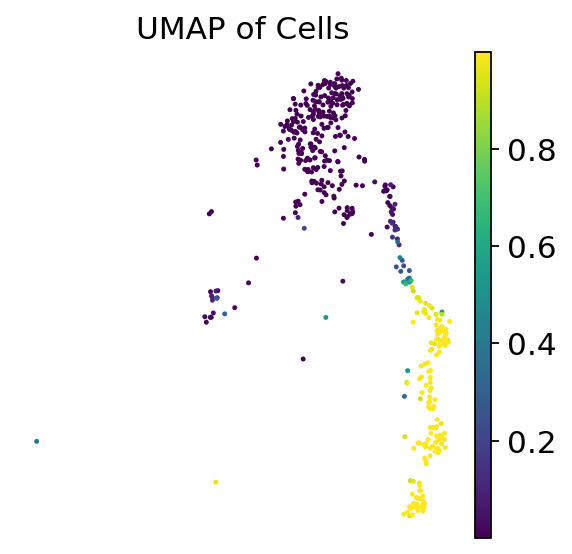

/tmp/ipykernel_31923/197518406.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


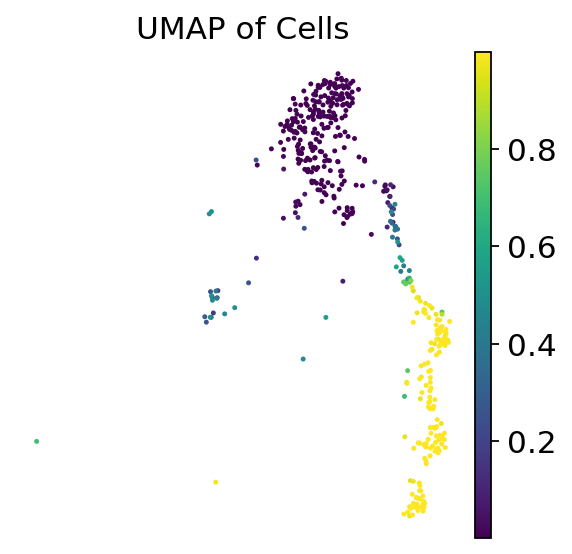

In [ ]:
#subset to stem cells and gonadotrophs
sc_gonado_subset = adata_mm[adata_mm.obs["cell_type_final"].isin(["Stem_cells","Gonadotrophs"])]

#calculate pseudotime values
sc_gonado_subset.obs["sc_gonado_pseudotime"] = (
    sc_gonado_subset.obs["proba_Gonadotrophs"] - sc_gonado_subset.obs["proba_Stem_cells"] + 1) / 2


#Plot cell types, cell type uncertainty, SC probability, Gon probability, SC-Gon pseudotime
plot_cells(sc_gonado_subset,"cell_type_final", palette = cell_type_palette, name="sc_gonado") # Figure 5C
plot_cells(sc_gonado_subset,"cell_type_uncertainty", name="sc_gonado")
plot_cells(sc_gonado_subset,"proba_Stem_cells", name="sc_gonado")
plot_cells(sc_gonado_subset,"proba_Gonadotrophs", name="sc_gonado")
plot_cells(sc_gonado_subset,"sc_gonado_pseudotime", name="sc_gonado") # Figure 5C


### Plot gene expression against pseudotime values

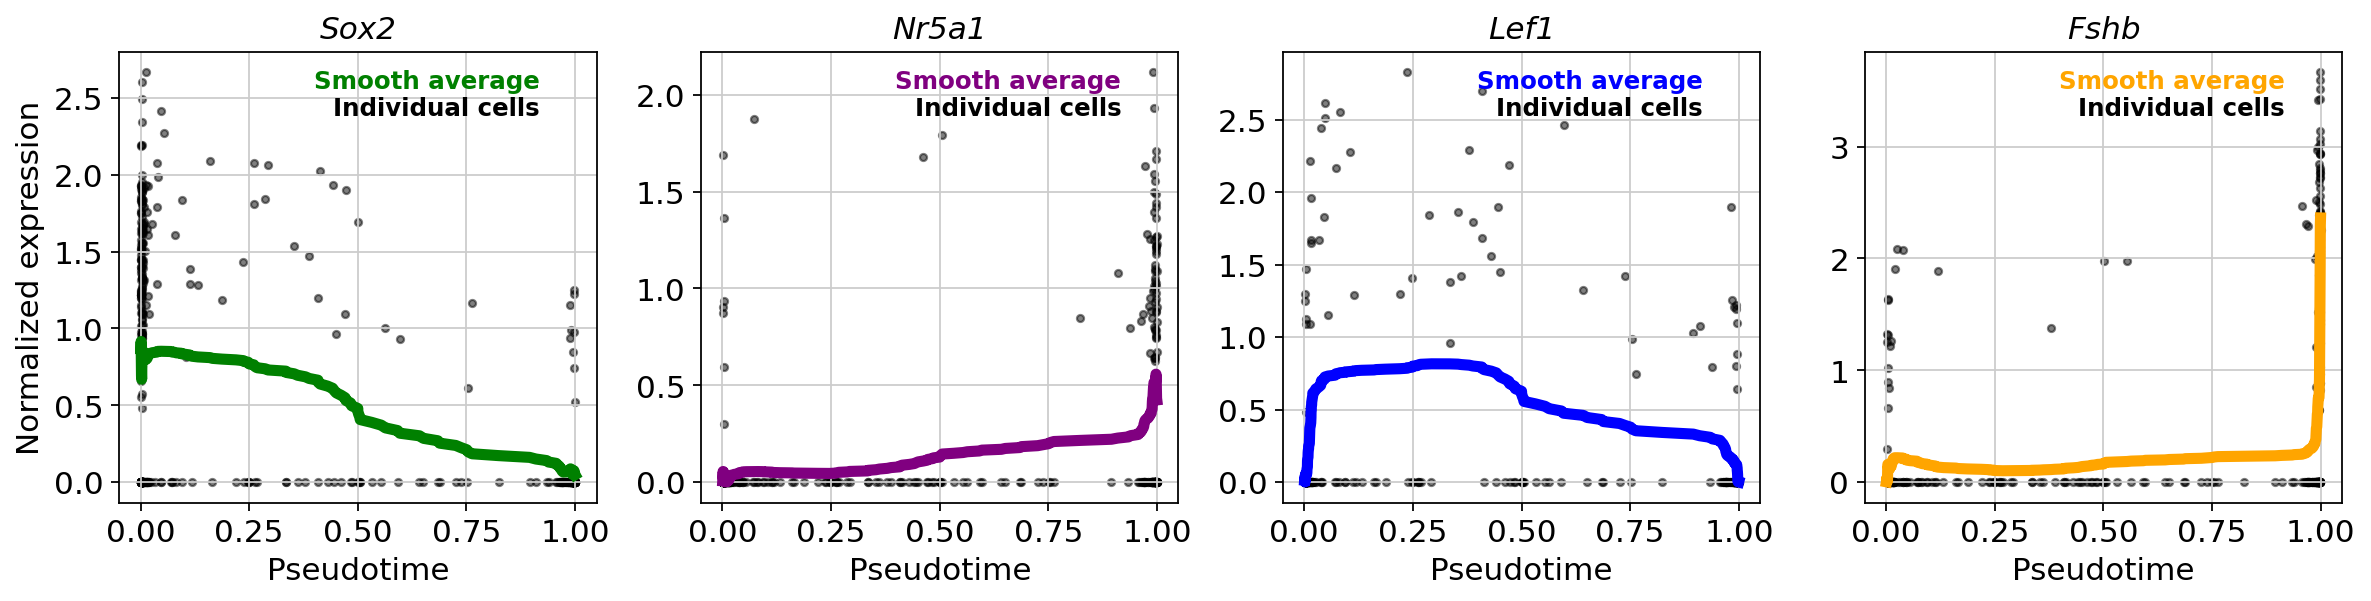

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

genes = {"Sox2":"green","Nr5a1":"purple","Lef1":"blue","Fshb":"orange"}

pt = sc_gonado_subset.obs["sc_gonado_pseudotime"].values
order = np.argsort(pt)
pt = pt[order]

fig, axes = plt.subplots(1, 4, figsize=(15,4), sharex=True)
for ax,(gene,color) in zip(axes, genes.items()):
    expr = sc_gonado_subset[:,gene].X.toarray().ravel()[order]
    ax.scatter(pt, expr, s=10, alpha=0.5, color="black")
    ax.plot(pt, gaussian_filter1d(expr, sigma=len(expr)*0.03), color=color, lw=5)
    ax.text(0.88, 0.96, "Smooth average", transform=ax.transAxes, ha="right", va="top", fontsize=11, fontweight="bold", color=color)
    ax.text(0.88, 0.9, "Individual cells", transform=ax.transAxes, ha="right", va="top", fontsize=11, fontweight="bold", color="black")
    ax.set_title(gene, style="italic")
    ax.set_xlabel("Pseudotime")
axes[0].set_ylabel("Normalized expression")
plt.tight_layout()
plt.savefig(f"figures/pseudotime_vs_expression.png", dpi=800)
plt.savefig(f"figures/pseudotime_vs_expression.svg", format="svg", bbox_inches="tight")
plt.show() # Figure 5D

### Generate a dot plot of canonical marker genes of pituitary gland cell types - Approx. 1 min


/tmp/ipykernel_31923/4164233444.py:28: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata_mm, mouse_markers, groupby="cell_type_final",save="_dotplot_markers.png",


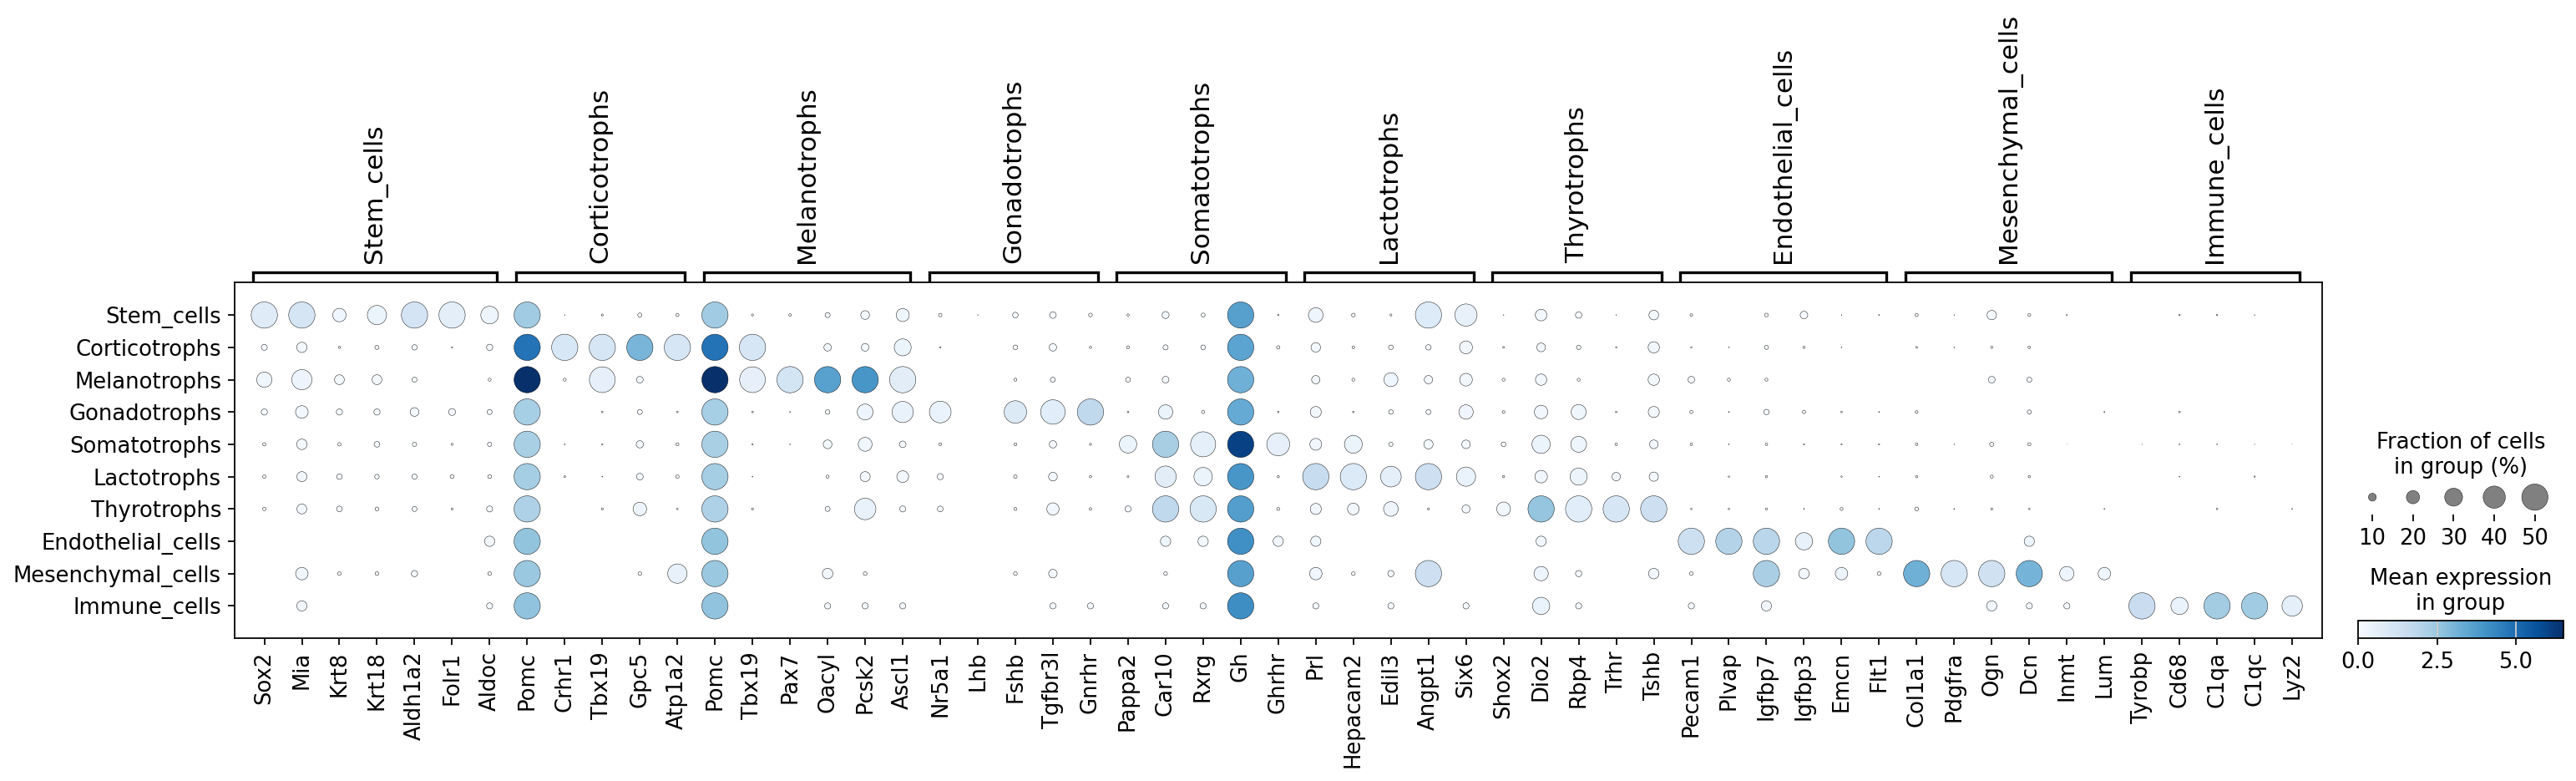

/tmp/ipykernel_31923/4164233444.py:30: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata_mm, mouse_markers, figsize=(13,5.3), groupby="cell_type_final",


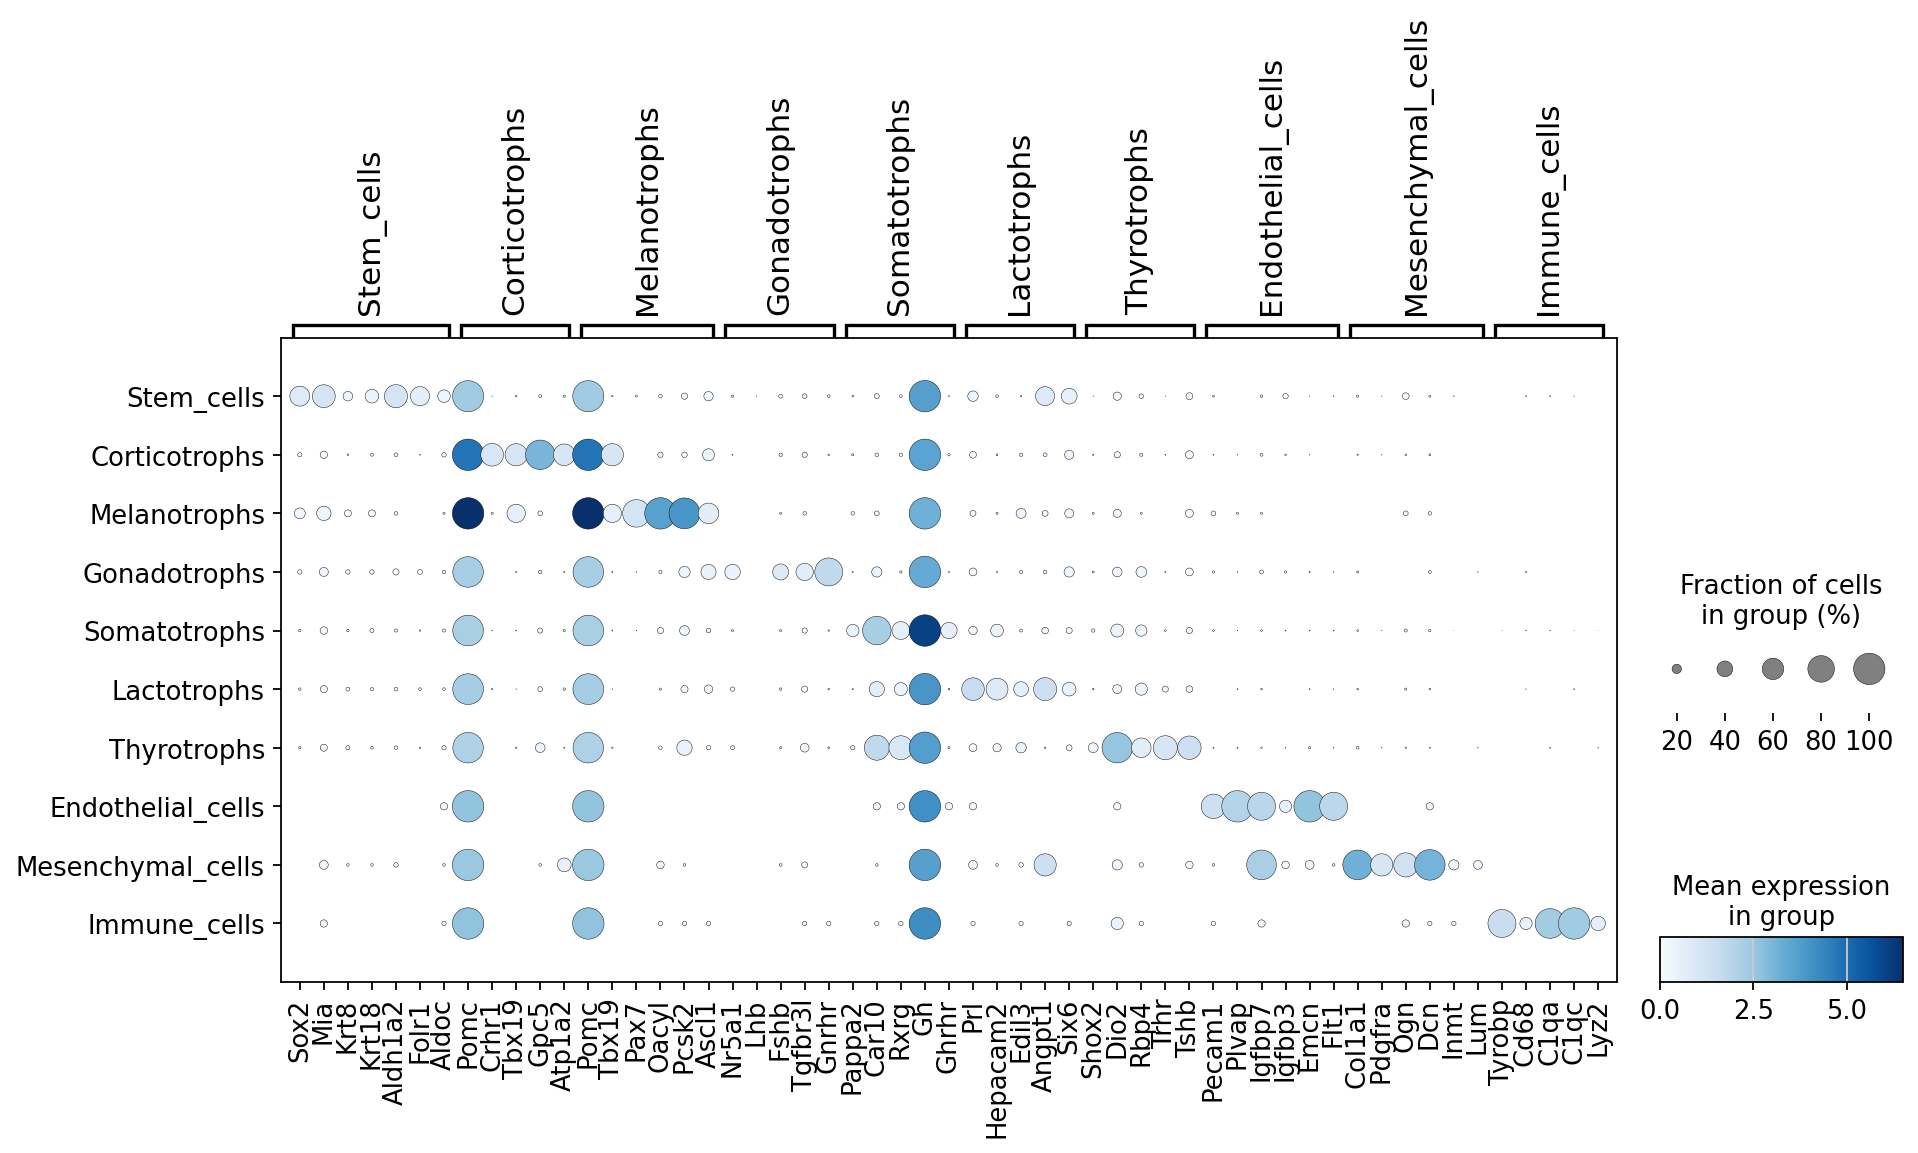

In [ ]:
mouse_markers = {"Stem_cells": ["Sox2", "Mia", "Krt8", "Krt18","Aldh1a2", "Folr1", "Aldoc"],
    "Corticotrophs": ["Pomc", "Crhr1", "Tbx19", "Gpc5", "Tnt1", "Atp1a2"],
    "Melanotrophs": ["Pomc", "Tbx19", "Pax7", "Oacyl", "Pcsk2", "Ascl1" ],
    "Gonadotrophs": ["Nr5a1", "Lhb", "Fshb", "Tgfbr3l", "Gnrhr"],
    "Somatotrophs": ["Pappa2", "Car10", "Rxrg", "Gh", "Ghrhr"],
    "Lactotrophs": ["Prl", "Hepacam2", "Edil3", "Angpt1",  "Six6"],
    "Thyrotrophs": ["Shox2", "Dio2", "Rbp4", "Trhr", "Tshb" ],
    "Endothelial_cells": ["Pecam1", "Plvap", "Igfbp7", "Igfbp3", "Emcn", "Flt1" ],
    "Mesenchymal_cells": ["Col1a1", "Pdgfra", "Ogn", "Dcn", "Inmt", "Lum"],
    #"Pituicytes": [ "Fgf10", "Rax", "Scn7a", "Gpc3", "Nkx2-1"],
    "Immune_cells": ["Tyrobp", "Cd68", "C1qa", "C1qc", "Lyz2" ]}

# Filter the marker genes to those included in the object
mouse_markers = {k: [x for x in v if x in adata_mm.var_names] for k, v in mouse_markers.items()}

# Extract the intended order from your dictionary keys
cell_type_order = ["Stem_cells", "Corticotrophs", "Melanotrophs", "Gonadotrophs", "Somatotrophs", "Lactotrophs", "Thyrotrophs", "Endothelial_cells", "Mesenchymal_cells", "Immune_cells"]

#only keep those that are in cell_type_final
cell_type_order = [x for x in cell_type_order if x in adata_mm.obs["cell_type_final"].unique()]

# Cast the observation column to a Categorical type with the strict order
adata_mm.obs["cell_type_final"] = pd.Categorical(adata_mm.obs["cell_type_final"],
    categories=cell_type_order,
    ordered=True
)

sc.pl.dotplot(adata_mm, mouse_markers, groupby="cell_type_final",save="_dotplot_markers.png",
              cmap="Blues", dot_max=0.5,use_raw=False) # Figure 4B
sc.pl.dotplot(adata_mm, mouse_markers, figsize=(13,5.3), groupby="cell_type_final",
              save="_dotplot_markers.svg",cmap="Blues",use_raw=False)

### Generate a dot plot of highly specific markers from the Consensus Pituitary Atlas. - Approx. 1 min


In [ ]:
!wget https://raw.githubusercontent.com/BKover99/epitome_tools_star_protocols/main/cell_typing_markers.csv

--2026-08-25 08:11:01--  https://raw.githubusercontent.com/BKover99/epitome_tools_star_protocols/main/cell_typing_markers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 146489 (143K) [text/plain]
Saving to: ‘cell_typing_markers.csv’

cell_typing_markers 100%[===================>] 143.06K  --.-KB/s    in 0.01s   

2026-08-25 08:11:01 (10.9 MB/s) - ‘cell_typing_markers.csv’ saved [146489/146489]



In [ ]:
# Load the data
ct_markers = pd.read_csv("/content/cell_typing_markers.csv")
ct_markers = ct_markers[ct_markers["avg_expr"] > 0]
# Sort by p-value (ascending) and logfc (descending)
ct_markers = ct_markers.sort_values(by=["pval", "log2fc"], ascending=[True, False])

# Keep the top 5 genes for each cell type
ct_markers = ct_markers.groupby("celltype").head(5)

# Aggregate the genes into a list for each cell type and convert to a dictionary
ct_markers_dict = ct_markers.groupby("celltype")["gene"].apply(list).to_dict()

# View the result
ct_markers_dict

{'Corticotrophs': ['Crhr1', 'Alpk2', 'Qrfpr', 'AW551984', 'Tekt1'],
 'Endothelial_cells': ['Adgrl4', 'Flt1', 'Fabp4', 'Plvap', 'Kdr'],
 'Gonadotrophs': ['Gnrhr', 'Nr5a1', 'Bean1', 'Vegfd', 'Igdcc4'],
 'Immune_cells': ['Ccl4', 'Cd86', 'C1qc', 'Ms4a7', 'Il1b'],
 'Lactotrophs': ['Hepacam2', 'Gm47888', 'Insyn1', 'Cdkl4', 'Alk'],
 'Melanotrophs': ['Oacyl', 'Pax7', 'Grik1', 'Gulo', 'Pcsk2'],
 'Mesenchymal_cells': ['Dcn', 'Apod', 'Pdgfra', 'Lum', 'Col1a1'],
 'Pituicytes': ['Lrrtm3', 'Scn7a', 'Gldc', 'Fgf10', 'Cdh19'],
 'Somatotrophs': ['Ghrhr', 'Pappa2', 'Car10', 'Gm47691', 'Mmp27'],
 'Stem_cells': ['Cdh26', 'Agr3', 'Alox12e', 'Klhl31', 'Grhl2'],
 'Thyrotrophs': ['Trhr', 'Dio2', 'Vdr', 'Jph4', 'Kcnk9']}

/tmp/ipykernel_31923/2275800788.py:18: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata_mm, ct_markers_dict, groupby="predicted_cell_type",save="_dotplot_cpa_markers.png",


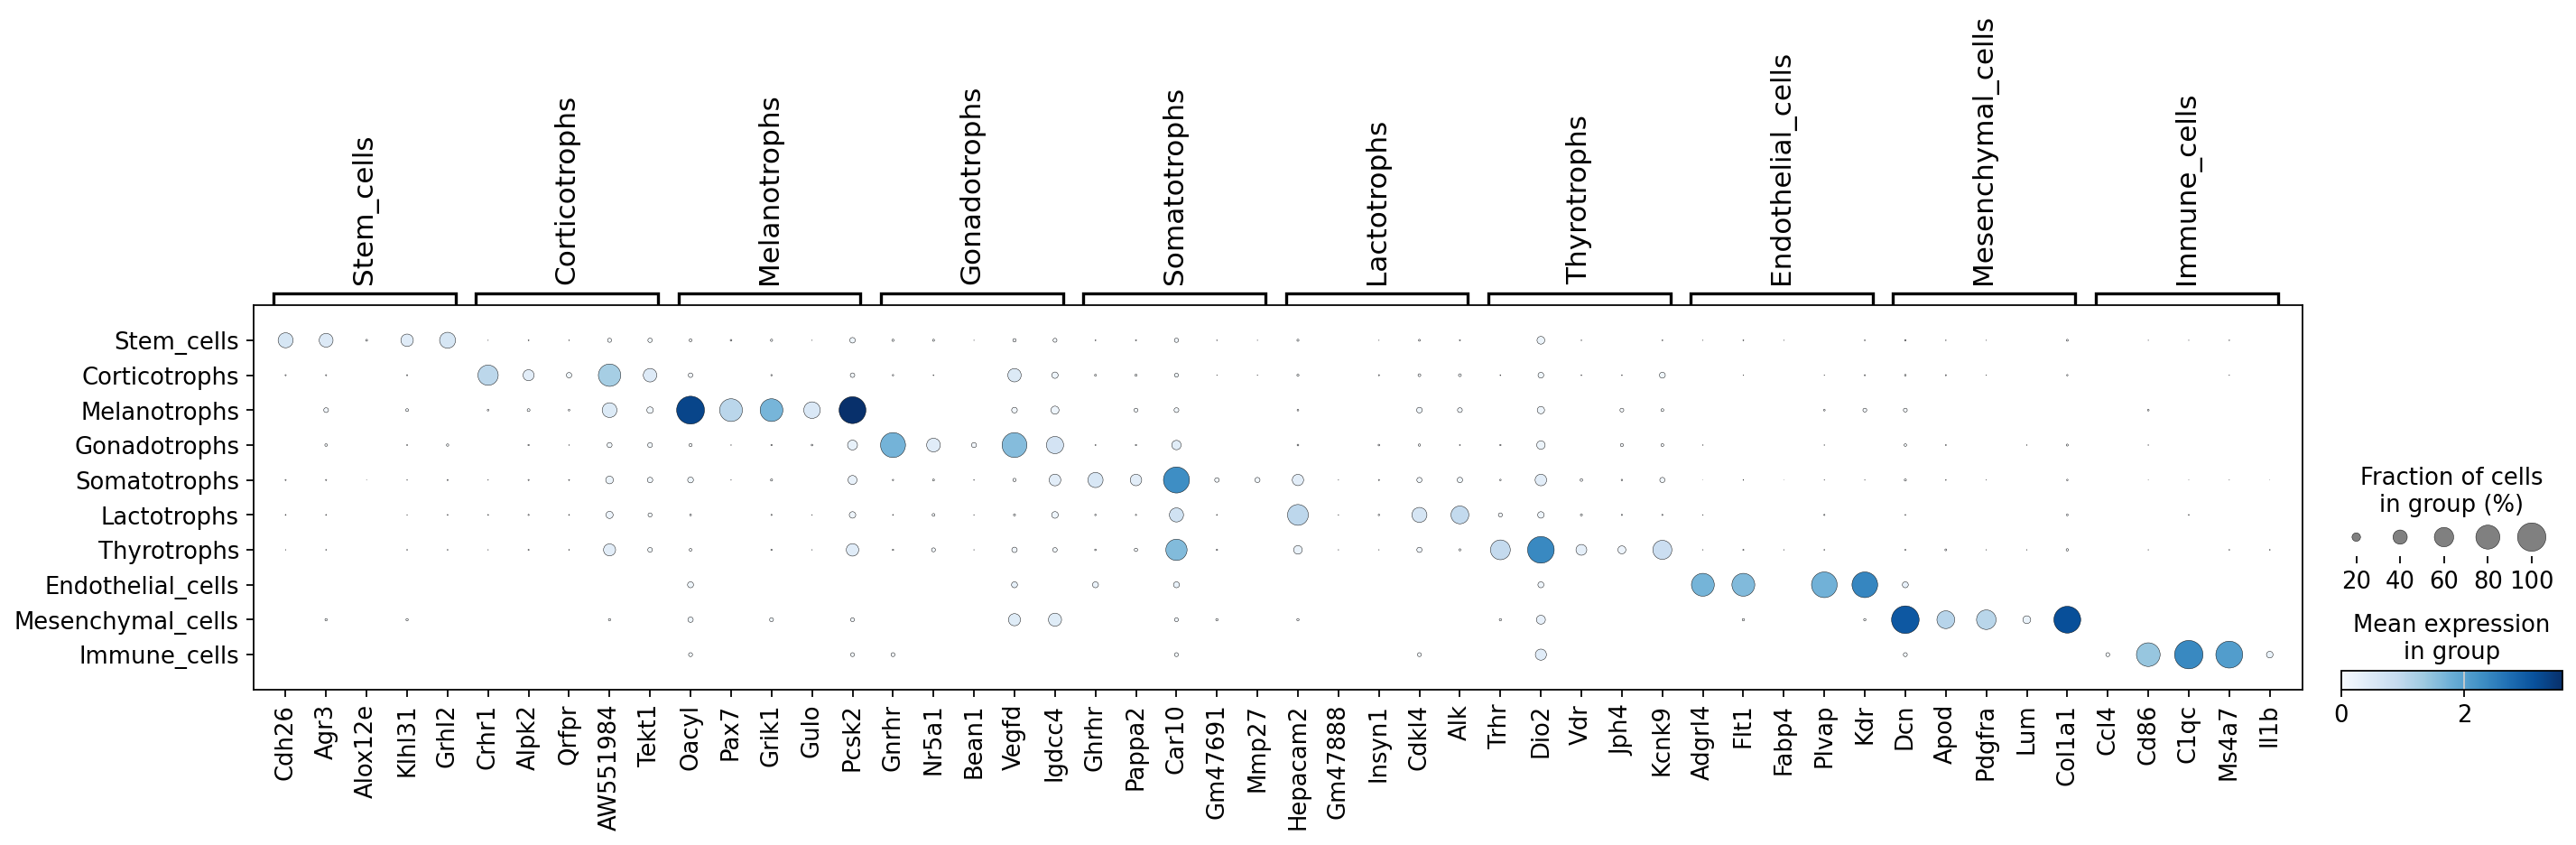

/tmp/ipykernel_31923/2275800788.py:21: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata_mm, ct_markers_dict,figsize=(13,5.3), groupby="predicted_cell_type",


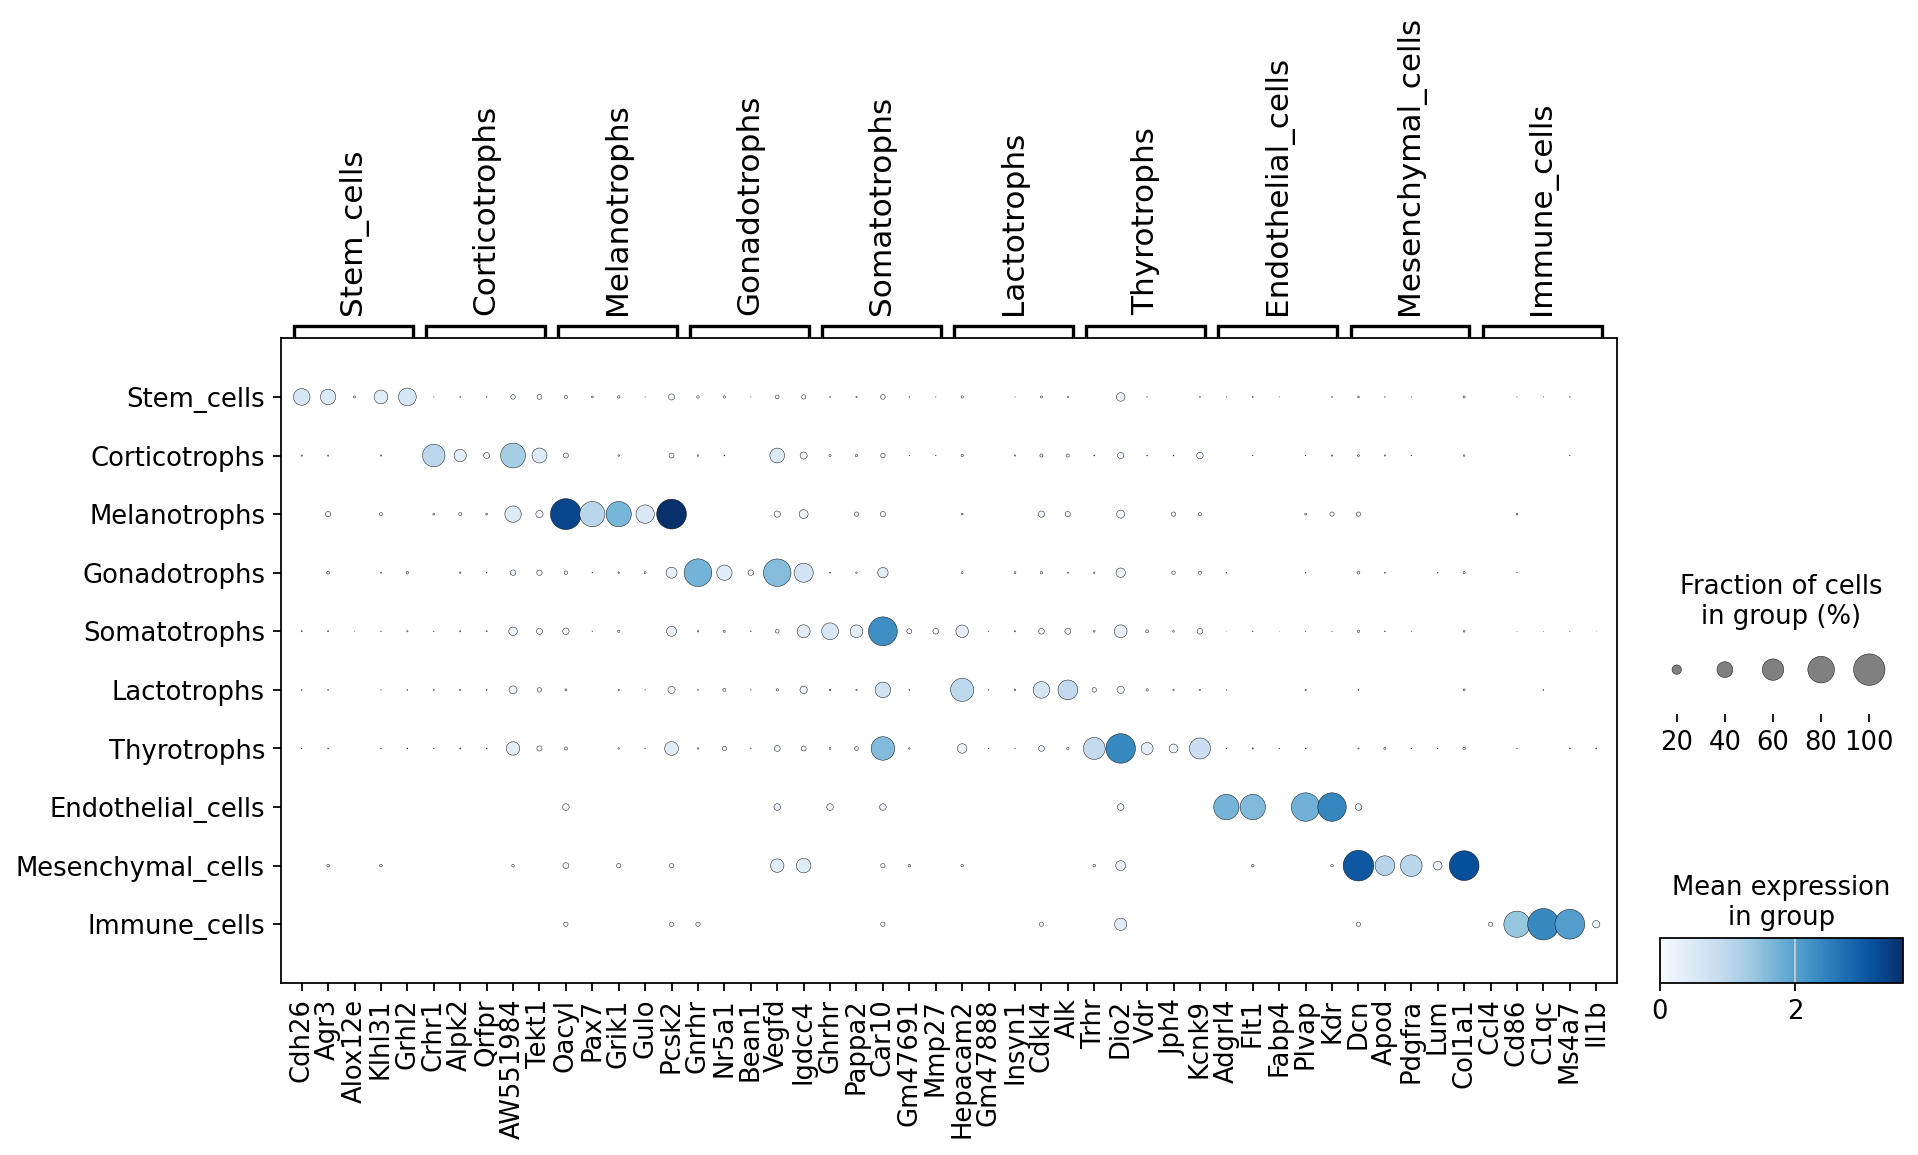

In [ ]:
# Filter the marker genes to those included in the object
ct_markers_dict = {k: [x for x in v if x in adata_mm.var_names] for k, v in ct_markers_dict.items()}

# Cast the observation column to a Categorical type with strict order
adata_mm.obs["predicted_cell_type"] = pd.Categorical(
    adata_mm.obs["predicted_cell_type"],
    categories=cell_type_order,
    ordered=True
)

# Filter dictionary to only include cell types present, maintaining order
ct_markers_dict = {
    k: ct_markers_dict[k] for k in cell_type_order
    if k in ct_markers_dict
}


sc.pl.dotplot(adata_mm, ct_markers_dict, groupby="predicted_cell_type",save="_dotplot_cpa_markers.png",
              cmap="Blues", use_raw=False) # Figure 4C

sc.pl.dotplot(adata_mm, ct_markers_dict,figsize=(13,5.3), groupby="predicted_cell_type",
              save="_dotplot_cpa_markers.svg",cmap="Blues",use_raw=False)

### Saving objects and exporting to Seurat (see R script for reading into Seurat at: Github/)

In [ ]:
adata_mm.write("/content/drive/MyDrive/star_protocols_paper/mouse_multiome_rna.h5ad")

________________________________________________________


### Load ATAC dataset

Importing fragments - Approx. 15 min

In [ ]:
# when re-running the notebook, you might want to remove the previous object and re-generate it
#!rm "/content/drive/MyDrive/star_protocols_paper/mouse_multiome_atac.h5ad"

In [ ]:
#make folder if doesn't exist
import os
if not os.path.exists("/content/drive/MyDrive/star_protocols_paper"):
  os.makedirs("/content/drive/MyDrive/star_protocols_paper")

import snapatac2 as snap
adata_atac_mm = snap.pp.import_fragments(
    fragment_file = "/content/zenodo/SRX30501234_atac_outs/fragments.tsv.gz",
    file = "/content/drive/MyDrive/star_protocols_paper/mouse_multiome_atac.h5ad",
    chrom_sizes=snap.genome.mm10,
    min_num_fragments=1500,
    sorted_by_barcode=False,
    #chunk_size=50000, n_jobs=8, #settings on high RAM instance
    chunk_size=1000, n_jobs=2, # settings on low RAM free instance
    tempdir="/content/", backend='hdf5')
adata_atac_mm.close()

### Continuing from checkpoint

In [ ]:
#load back object
import snapatac2 as snap
adata_atac_mm = snap.read("/content/drive/MyDrive/star_protocols_paper/mouse_multiome_atac.h5ad")
adata_atac_mm

AnnData object with n_obs x n_vars = 4199 x 0 backed at '/content/drive/MyDrive/star_protocols_paper/mouse_multiome_atac.h5ad'
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import snapatac2 as snap
import numpy as np

def violinplot(ax,adata,col,vals):
    """function to generate violin plots with red cut-offs"""
    values = adata.obs[col]
    sns.violinplot(y=values, ax=ax)
    for v in vals:
        ax.axhline(v, color="red")
        ax.set_title(col)
        ax.set_ylabel('')

def qc(adata):
    """function to filter cells based on TSSE and fragment count"""

    adata.obs["log_n_frags"] = np.log2(adata.obs['n_fragment'] )
    log_n_frags = mad_outlier(adata, "log_n_frags", 3, upper_only=False, value=True)

    # Create a 2x3 grid of subplots (5 plots, one empty)
    fig, axs = plt.subplots(1, 2, figsize=(5.5, 2.75))
    axs = axs.flatten()

    violinplot(axs[0], adata, "log_n_frags", log_n_frags + [10.55])
    violinplot(axs[1], adata, 'tsse', [7])
    plt.tight_layout()

    plt.savefig(f"figures/vlnplot_atac.png", dpi=800)
    plt.savefig(f"figures/vlnplot_atac.svg", format="svg", bbox_inches="tight")

    plt.show()

    keep = np.array(adata.obs_names)[~mad_outlier(adata, "log_n_frags", 3).to_numpy() ]

    return fig, keep

### QC - Approx. 15 min

  0%|                                              | 0.00/24.0M [00:00<?, ?B/s]

Initial dataset:      4,199 droplets × 0 features
After tile matrix:    4,199 cells × 526,765 features


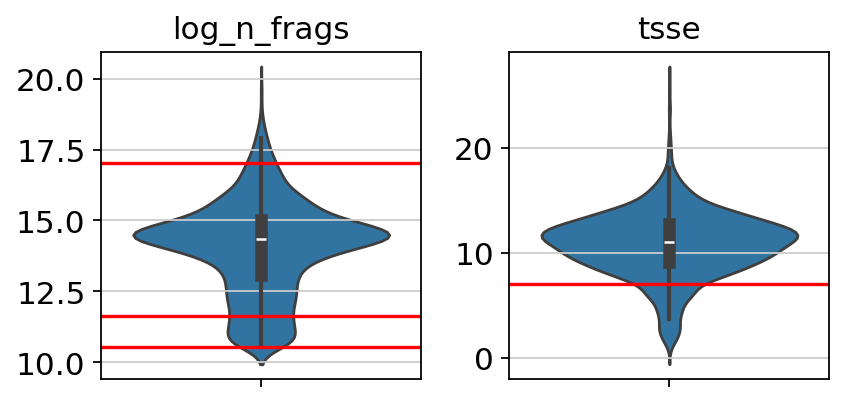

After QC:  3,395 cells × 526,765 features
After feature select: 3,395 cells × 526,765 features
After Scrublet:       3,395 cells × 526,765 features


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
snap.metrics.tsse(adata_atac_mm, snap.genome.mm10)

print(f"Initial dataset:      "
    f"{adata_atac_mm.shape[0]:,} droplets × "
    f"{adata_atac_mm.shape[1]:,} features")

snap.pp.add_tile_matrix(adata_atac_mm, bin_size=5000,)
print(f"After tile matrix:    "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

vln_plots, keep = qc(adata_atac_mm) # Figure 2A

#SnapATAC2 specific filtering function
adata_atac_mm.subset(keep)

snap.pp.filter_cells(adata_atac_mm, min_tsse=7)

print(f"After QC:  "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

snap.pp.select_features(
    adata_atac_mm,
    n_features=30000)

print(f"After feature select: "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

snap.pp.scrublet(adata_atac_mm)
print(f"After Scrublet:       "
    f"{adata_atac_mm.shape[0]:,} cells × "
    f"{adata_atac_mm.shape[1]:,} features")

snap.tl.spectral(adata_atac_mm)
snap.tl.umap(adata_atac_mm)


In [ ]:
fig = snap.pl.umap(adata_atac_mm, show=False)
fig.update_traces(marker=dict(color="black", size=3))
fig.update_layout(width=400,height=400)

fig.show(config={
        "toImageButtonOptions": {
            "format": "svg",
            "filename": "atac_umap_unannotated"}})

In [ ]:
fig = snap.pl.umap(adata_atac_mm, show= False, color="doublet_probability") # Figure 2B
fig.update_layout(width=500,height=400)

fig.show(config={
        "toImageButtonOptions": {
            "format": "svg",
            "filename": "atac_umap_doublet"}})

In [ ]:
#removing doublets
snap.pp.filter_doublets(adata_atac_mm)
print(f"After doublet filter: "
    f"{adata_atac_mm.shape[0]:,} cells")

After doublet filter: 2,461 cells


In [ ]:
fig = snap.pl.umap(adata_atac_mm, show=False)
fig.update_traces(marker=dict(color="#1f77b4", size=3))
fig.update_layout(width=400,height=400)

fig.show(config={
        "toImageButtonOptions": {
            "format": "svg",
            "filename": "atac_umap_doublet_removed"}})

In [ ]:
adata_atac_mm.write(f"/content/drive/MyDrive/star_protocols_paper/filtered_adata.h5ad")
adata_atac_mm.close()

### Download Consensus Chromatin Landscape peaks - Approx. 1 min

The Consensus Chromatin Landscape includes a reproducible set of accessible genomic regions. For a better understanding, please consult Kövér et al. (2026) in Cell Reports

In [ ]:
!wget https://raw.githubusercontent.com/Andoniadou-Lab/consensus_pituitary_atlas/main/Consensus_Chromatin_Landscape/consensus_chromatin_landscape.bed

--2026-08-25 10:23:57--  https://raw.githubusercontent.com/Andoniadou-Lab/consensus_pituitary_atlas/main/Consensus_Chromatin_Landscape/consensus_chromatin_landscape.bed
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5886467 (5.6M) [text/plain]
Saving to: ‘consensus_chromatin_landscape.bed’

consensus_chromatin 100%[===================>]   5.61M  --.-KB/s    in 0.06s   

2026-08-25 10:23:57 (100 MB/s) - ‘consensus_chromatin_landscape.bed’ saved [5886467/5886467]



### Fragment counting in CCL peaks - Approx. 1 min

Fragment counting is performed as opposed to read counting, to remain consistent with the Consensus Pituitary Atlas, and also for reasons discussed in: https://doi.org/10.1038/s41592-023-02112-6

In [ ]:
#load back object
import snapatac2 as snap
adata_atac_mm = snap.read("/content/drive/MyDrive/star_protocols_paper/filtered_adata.h5ad")
peak_mat = snap.pp.make_peak_matrix(adata_atac_mm,
                                    peak_file= "/content/consensus_chromatin_landscape.bed",
                                    counting_strategy = "fragment",
                                    chunk_size=500 #adjust for RAM issues if needed
                                    )
peak_mat.write(f"/content/drive/MyDrive/star_protocols_paper/quantified_adata.h5ad")
adata_atac_mm.close()

/usr/lib/python3.13/functools.py:934: ImplicitModificationWarning:

Transforming to str index.



### Now lognormalising the fragment matrix. Also saving over the UMAP from the initial object

In [ ]:
adata_atac_mm = snap.read("/content/drive/MyDrive/star_protocols_paper/filtered_adata.h5ad")
peak_mat = snap.read("/content/drive/MyDrive/star_protocols_paper/quantified_adata.h5ad").to_memory()
sc.pp.normalize_total(peak_mat, target_sum=1e4)
sc.pp.log1p(peak_mat)
peak_mat.obsm["X_umap"] = adata_atac_mm.obsm["X_umap"]
adata_atac_mm.close()

### Running epitome_tools - Approx. 1-2 mins

In [ ]:
from epitome_tools.workflow import cell_type_workflow
import time

start_mm = time.time()

cell_type_workflow(
  peak_mat,
  modality="atac", #can take values "rna", "atac"
  in_place=True,
  species="mouse",
  smoothing = True )

end_mm = time.time()
print(f"Time taken for dataset: {end_mm - start_mm} seconds")

Percentage of features present in adata: 100.00%
At least 70% of the features are present in the adata object.
The dataset has passed the compatibility check.
Time taken for dataset: 155.08545231819153 seconds


/tmp/ipykernel_31923/197518406.py:3: FutureWarning:

Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.



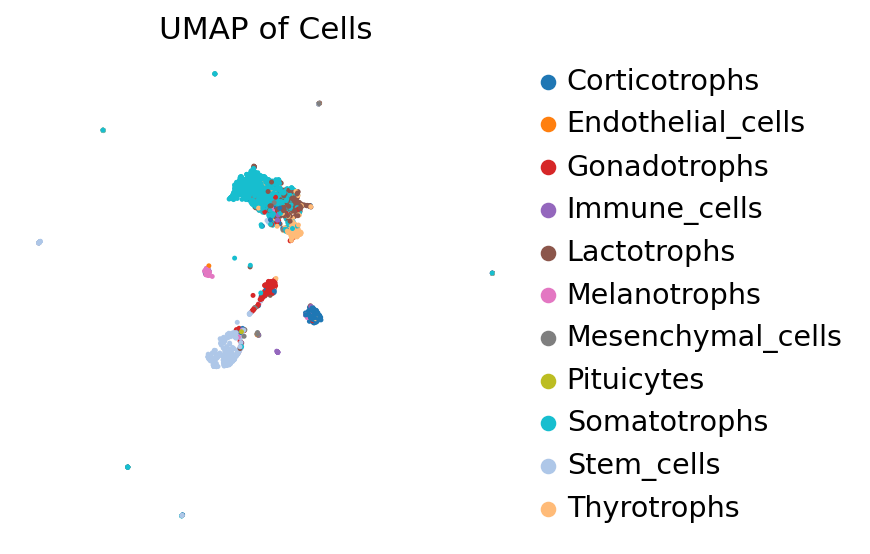

In [ ]:
plot_cells(peak_mat,'cell_type_final',palette=cell_type_palette, name="atac") # Figure 4D

### Visualising in RNA-space

In [ ]:
#download multiome onlist
!wget -P 10xMultiome/ https://teichlab.github.io/scg_lib_structs/data/10X-Genomics/gex_737K-arc-v1.txt.gz
!gunzip 10xMultiome/gex_737K-arc-v1.txt.gz
!wget -P 10xMultiome/ https://teichlab.github.io/scg_lib_structs/data/10X-Genomics/atac_737K-arc-v1.txt.gz
!gunzip 10xMultiome/atac_737K-arc-v1.txt.gz

--2026-08-25 10:27:10--  https://teichlab.github.io/scg_lib_structs/data/10X-Genomics/gex_737K-arc-v1.txt.gz
Resolving teichlab.github.io (teichlab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to teichlab.github.io (teichlab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2142553 (2.0M) [application/gzip]
Saving to: ‘10xMultiome/gex_737K-arc-v1.txt.gz’

gex_737K-arc-v1.txt 100%[===================>]   2.04M  --.-KB/s    in 0.04s   

2026-08-25 10:27:11 (53.2 MB/s) - ‘10xMultiome/gex_737K-arc-v1.txt.gz’ saved [2142553/2142553]

--2026-08-25 10:27:11--  https://teichlab.github.io/scg_lib_structs/data/10X-Genomics/atac_737K-arc-v1.txt.gz
Resolving teichlab.github.io (teichlab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to teichlab.github.io (teichlab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2465078 (2.4M) [a

In [ ]:
#create mapping from rna to atac barcodes
gex = pd.read_csv("/content/10xMultiome/gex_737K-arc-v1.txt",header=None)
atac = pd.read_csv('/content/10xMultiome/atac_737K-arc-v1.txt',header=None)

#mapping atac to gex
mapping = pd.DataFrame({'gex': gex[0], 'atac': atac[0]})
mapping_atac_to_gex= mapping.set_index('atac')['gex'].to_dict()

#mapping gex to cell type
mapping_gex_ct = adata_mm.obs['cell_type_final'].to_dict()

#extracting barcode sequence
peak_mat.obs["barcode"] = (peak_mat.obs_names.astype(str).str.split("-").str[0]
)

#mapping to atac barcode to RNA counterpart, and adding -1 to it
peak_mat.obs["barcode"] = peak_mat.obs["barcode"].map(mapping_atac_to_gex)
peak_mat.obs["barcode"] = peak_mat.obs["barcode"] + "-1"

#add cell type
peak_mat.obs["cell_type_final_rna"] = peak_mat.obs["barcode"].map(mapping_gex_ct)

In [ ]:
#keep where cell type is not na
peak_mat = peak_mat[peak_mat.obs["cell_type_final_rna"].notna()]

shared_barcodes = pd.Index(peak_mat.obs["barcode"]).intersection(adata_mm.obs_names)
peak_mat.obsm["X_umap"] = adata_mm[shared_barcodes].obsm["X_umap"]

/tmp/ipykernel_31923/1646143573.py:5: ImplicitModificationWarning:

Setting element `.obsm['X_umap']` of view, initializing view as actual.



/tmp/ipykernel_31923/702350890.py:3: FutureWarning:

Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.



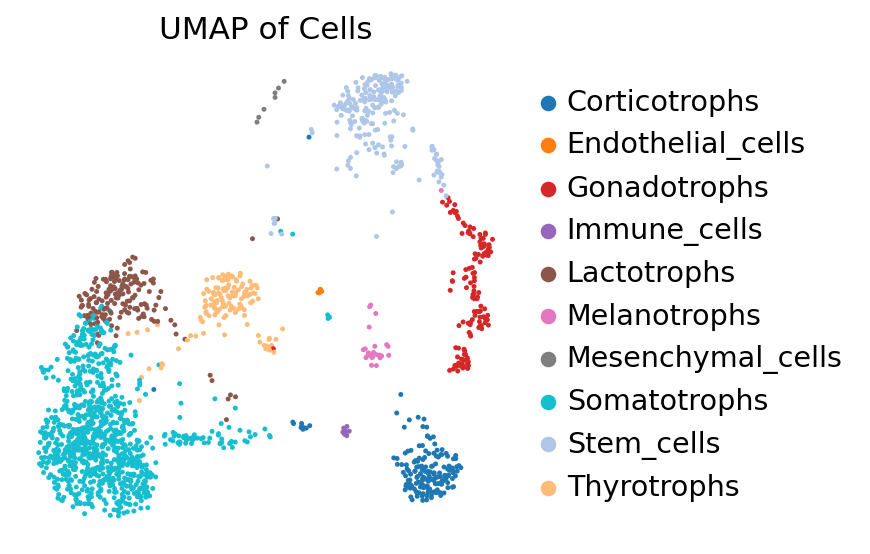

/tmp/ipykernel_31923/702350890.py:3: FutureWarning:

Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.



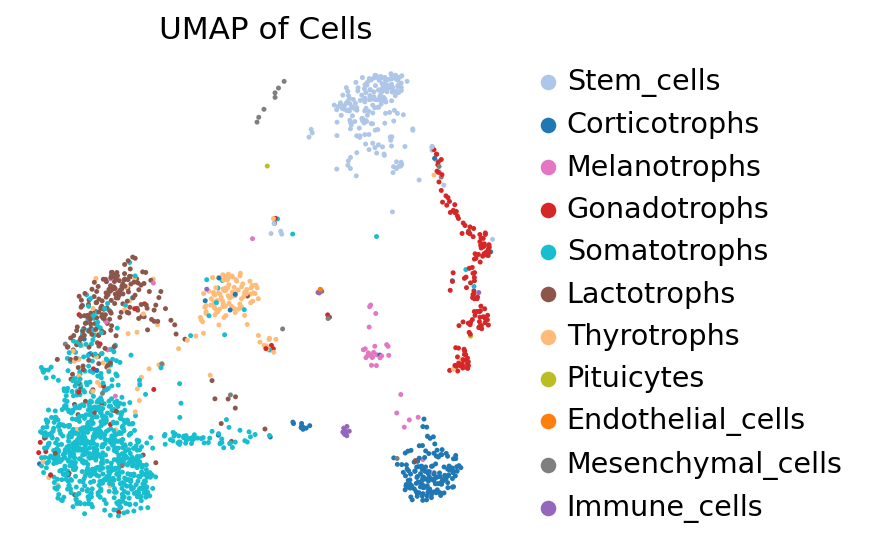

/tmp/ipykernel_31923/702350890.py:3: FutureWarning:

Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.



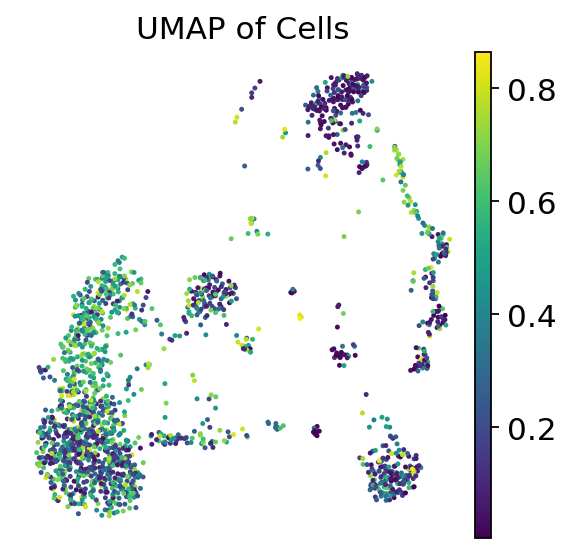

/tmp/ipykernel_31923/702350890.py:3: FutureWarning:

Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.



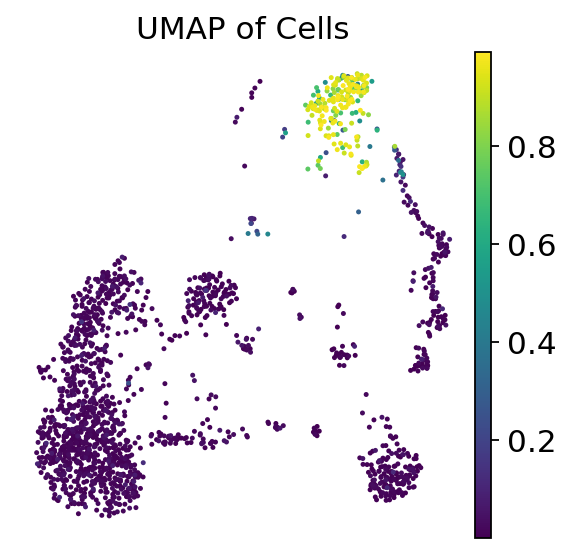

/tmp/ipykernel_31923/702350890.py:3: FutureWarning:

Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.



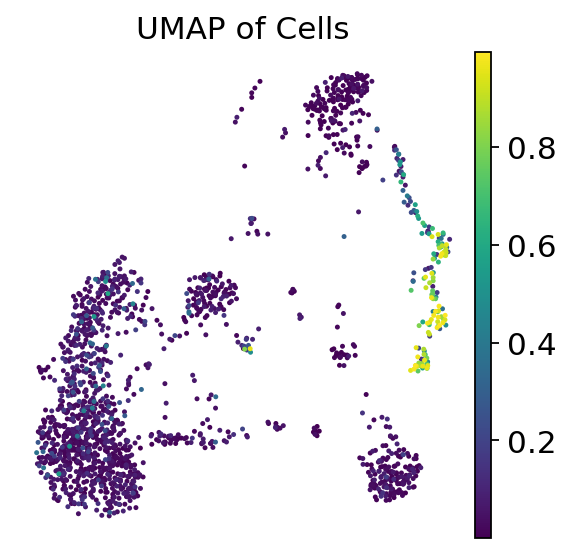

In [ ]:
plot_cells(peak_mat,"cell_type_final_rna", palette = cell_type_palette, name="rna_annotations")
plot_cells(peak_mat,"cell_type_final", palette = cell_type_palette, name="atac_annotations") # Figure 4E
plot_cells(peak_mat,"cell_type_uncertainty", name="atac", sort=False) # Figure 5E
plot_cells(peak_mat,"proba_Stem_cells", name="atac") # Figure 5F
plot_cells(peak_mat,"proba_Gonadotrophs", name="atac")

/tmp/ipykernel_31923/1111815390.py:5: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



/tmp/ipykernel_31923/197518406.py:3: FutureWarning:

Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.



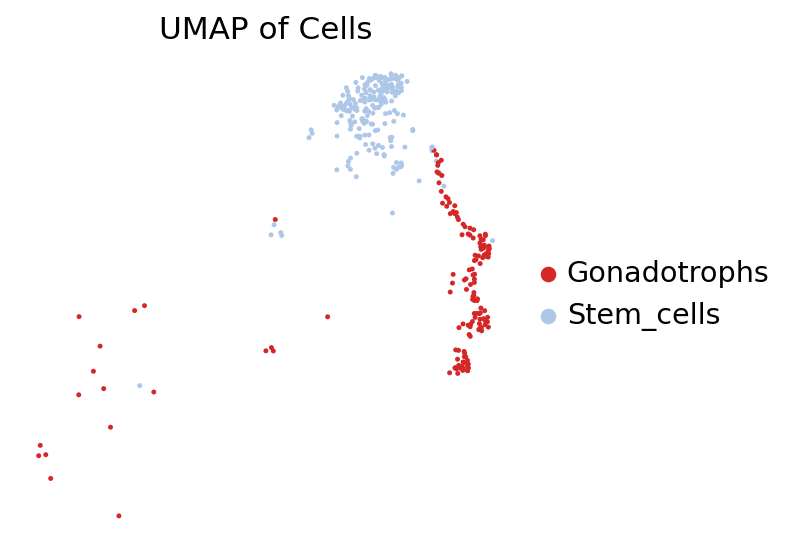

/tmp/ipykernel_31923/197518406.py:3: FutureWarning:

Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.



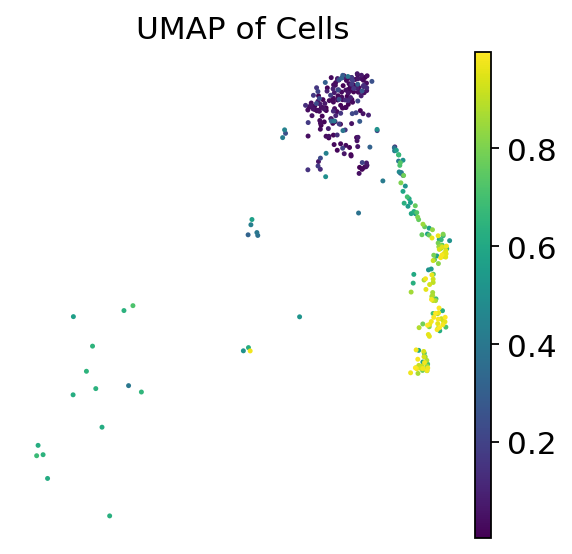

In [ ]:
#subset to stem cells and gonadotrophs
sc_gonado_subset = peak_mat[peak_mat.obs["cell_type_final"].isin(["Stem_cells","Gonadotrophs"])]

#calculate pseudotime values
sc_gonado_subset.obs["sc_gonado_pseudotime"] = (
    sc_gonado_subset.obs["proba_Gonadotrophs"] - sc_gonado_subset.obs["proba_Stem_cells"] + 1) / 2

#Plot cell types, cell type uncertainty, SC probability, Gon probability, SC-Gon pseudotime
plot_cells(sc_gonado_subset,"cell_type_final", palette = cell_type_palette, name="sc_gonado") # Figure 5G
plot_cells(sc_gonado_subset,"sc_gonado_pseudotime", name="sc_gonado") # Figure 5G

### Quantifying overlap in labels

In [ ]:
df = peak_mat.obs[["cell_type_final", "cell_type_final_rna"]]

pct_equal = (df["cell_type_final"].astype(str)== df["cell_type_final_rna"].astype(str)).mean() * 100

print(f"{pct_equal:.2f}%")

87.68%


### Saving ATAC data

In [ ]:
peak_mat.write("/content/drive/MyDrive/star_protocols_paper/mouse_multiome_atac_final.h5ad")

### Visualising known marker peaks

In [ ]:
peak_mat = sc.read("/content/drive/MyDrive/star_protocols_paper/mouse_multiome_atac_final.h5ad")

In [ ]:
!wget https://raw.githubusercontent.com/BKover99/epitome_tools_star_protocols/main/cell_typing_markers_atac.csv

--2026-08-25 10:27:28--  https://raw.githubusercontent.com/BKover99/epitome_tools_star_protocols/main/cell_typing_markers_atac.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4901526 (4.7M) [text/plain]
Saving to: ‘cell_typing_markers_atac.csv’

cell_typing_markers 100%[===================>]   4.67M  --.-KB/s    in 0.05s   

2026-08-25 10:27:28 (98.9 MB/s) - ‘cell_typing_markers_atac.csv’ saved [4901526/4901526]



In [ ]:
# Load the data
ct_markers = pd.read_csv("/content/cell_typing_markers_atac.csv")
# Sort by p-value
ct_markers = ct_markers.sort_values(by=["pval", "log2fc"], ascending=[True, False])

# Keep the top 5 genes for each cell type
ct_markers = ct_markers.groupby("celltype").head(5)

# Aggregate the genes into a list for each cell type and convert to a dictionary
ct_markers_dict = ct_markers.groupby("celltype")["peak"].apply(list).to_dict()

# View the result
ct_markers_dict["Stem_cells"]

['chr14:103850033-103850534',
 'chr3:23135438-23135939',
 'chr6:15829753-15830254',
 'chr10:31023271-31023772',
 'chr10:100198965-100199466']

/tmp/ipykernel_31923/1472644357.py:18: FutureWarning:

Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.



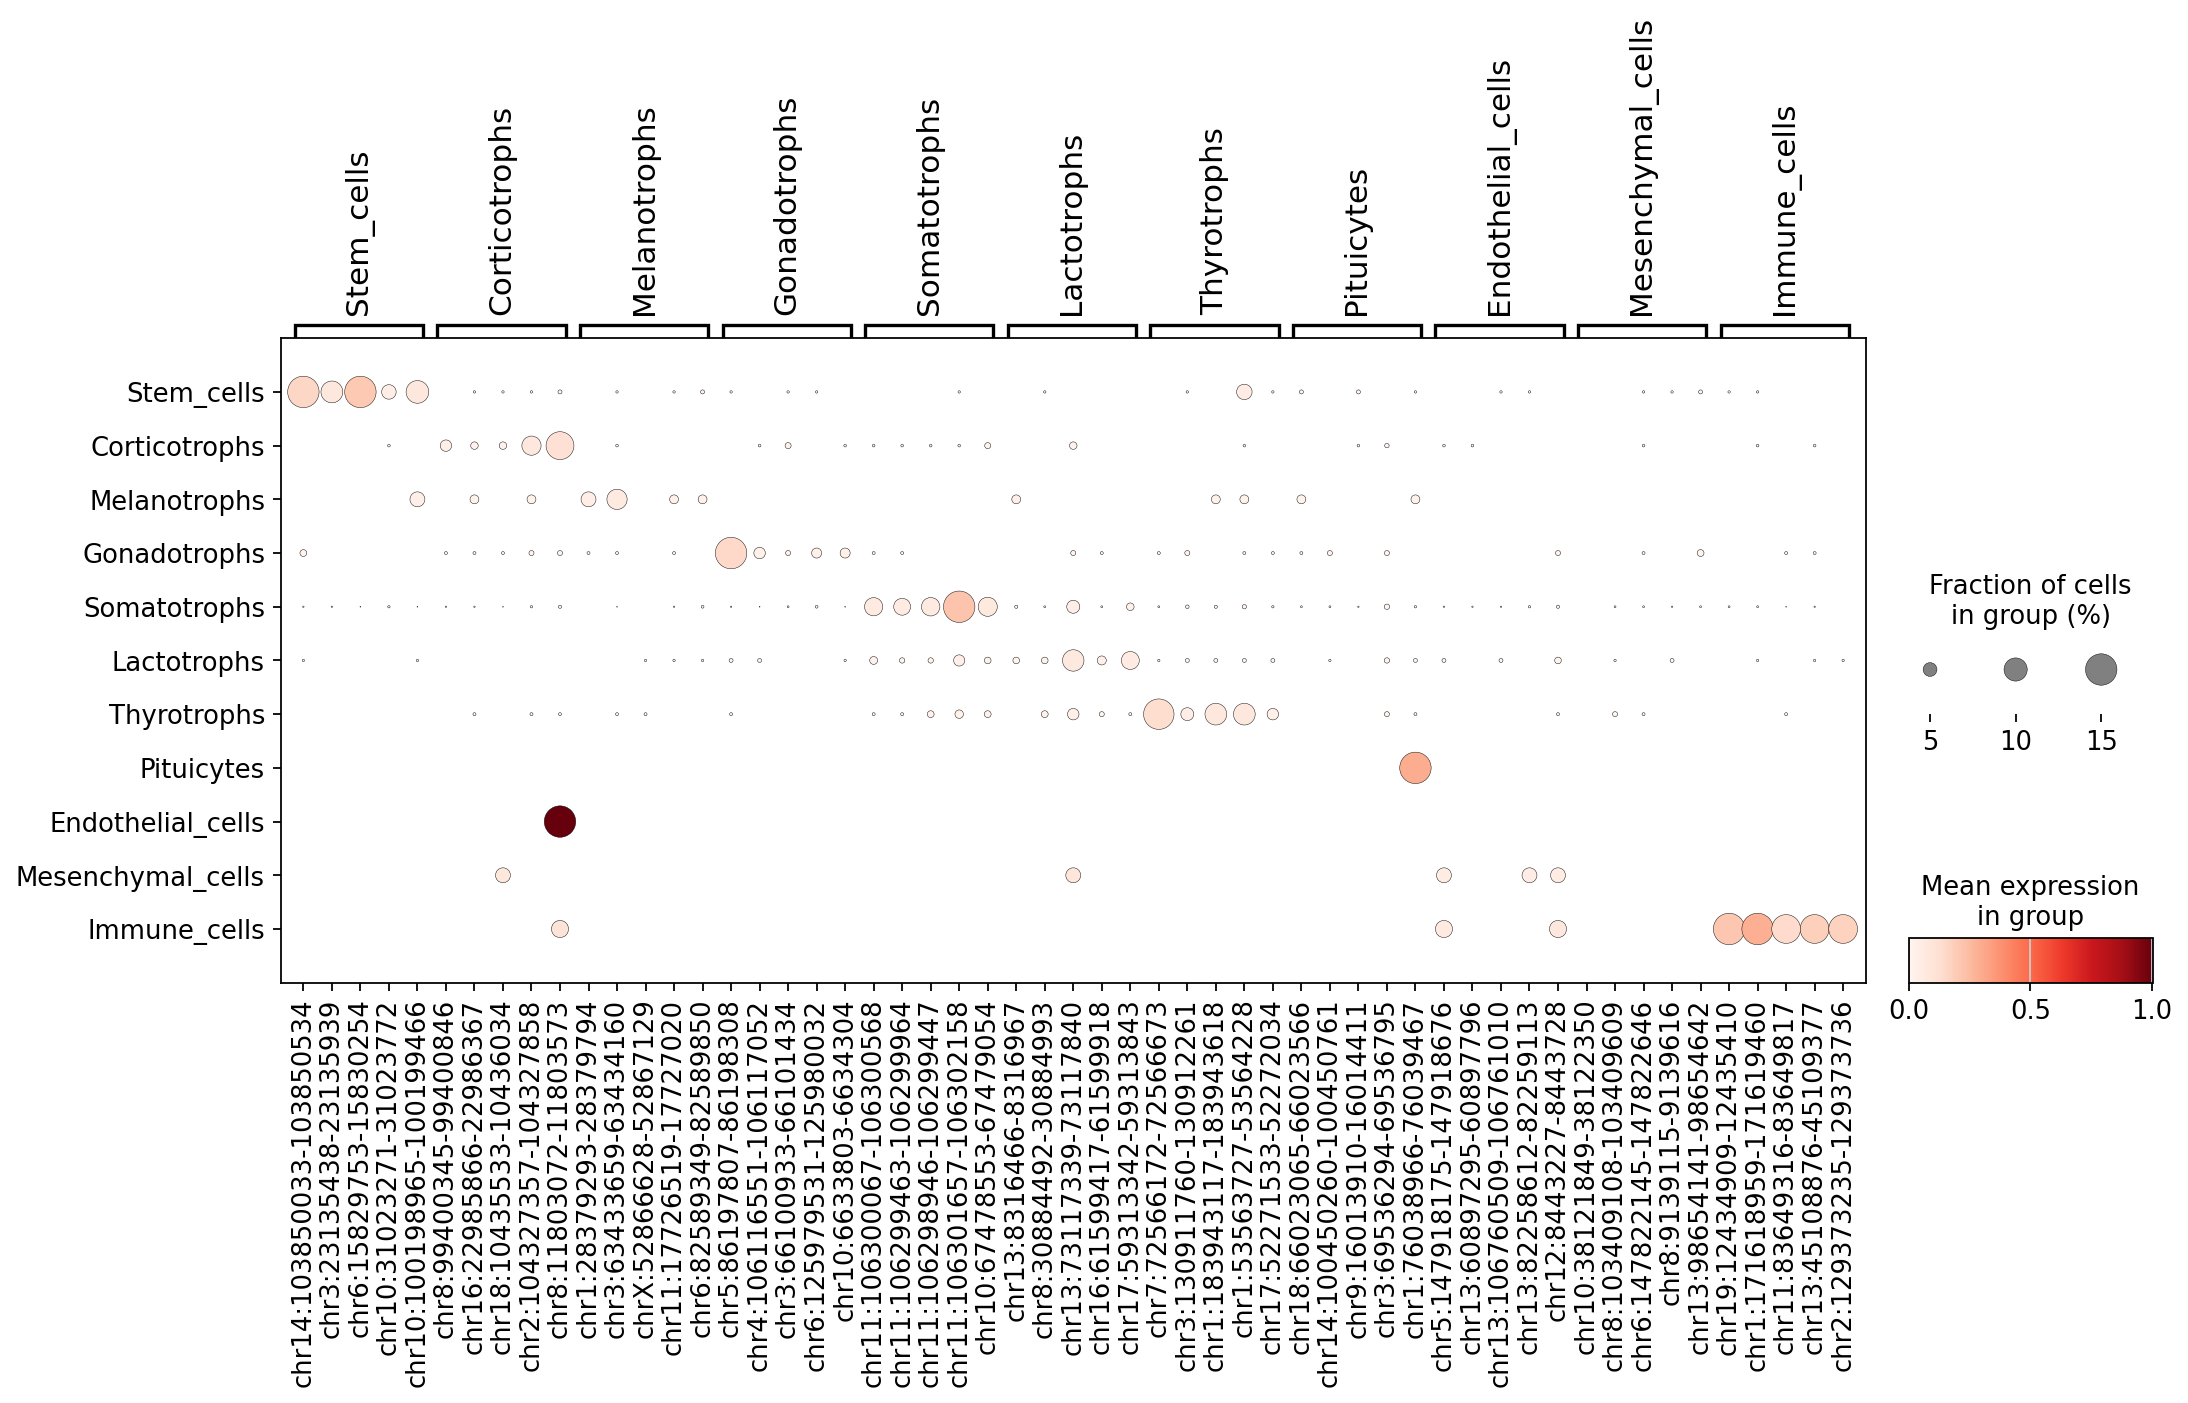

/tmp/ipykernel_31923/1472644357.py:19: FutureWarning:

Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.



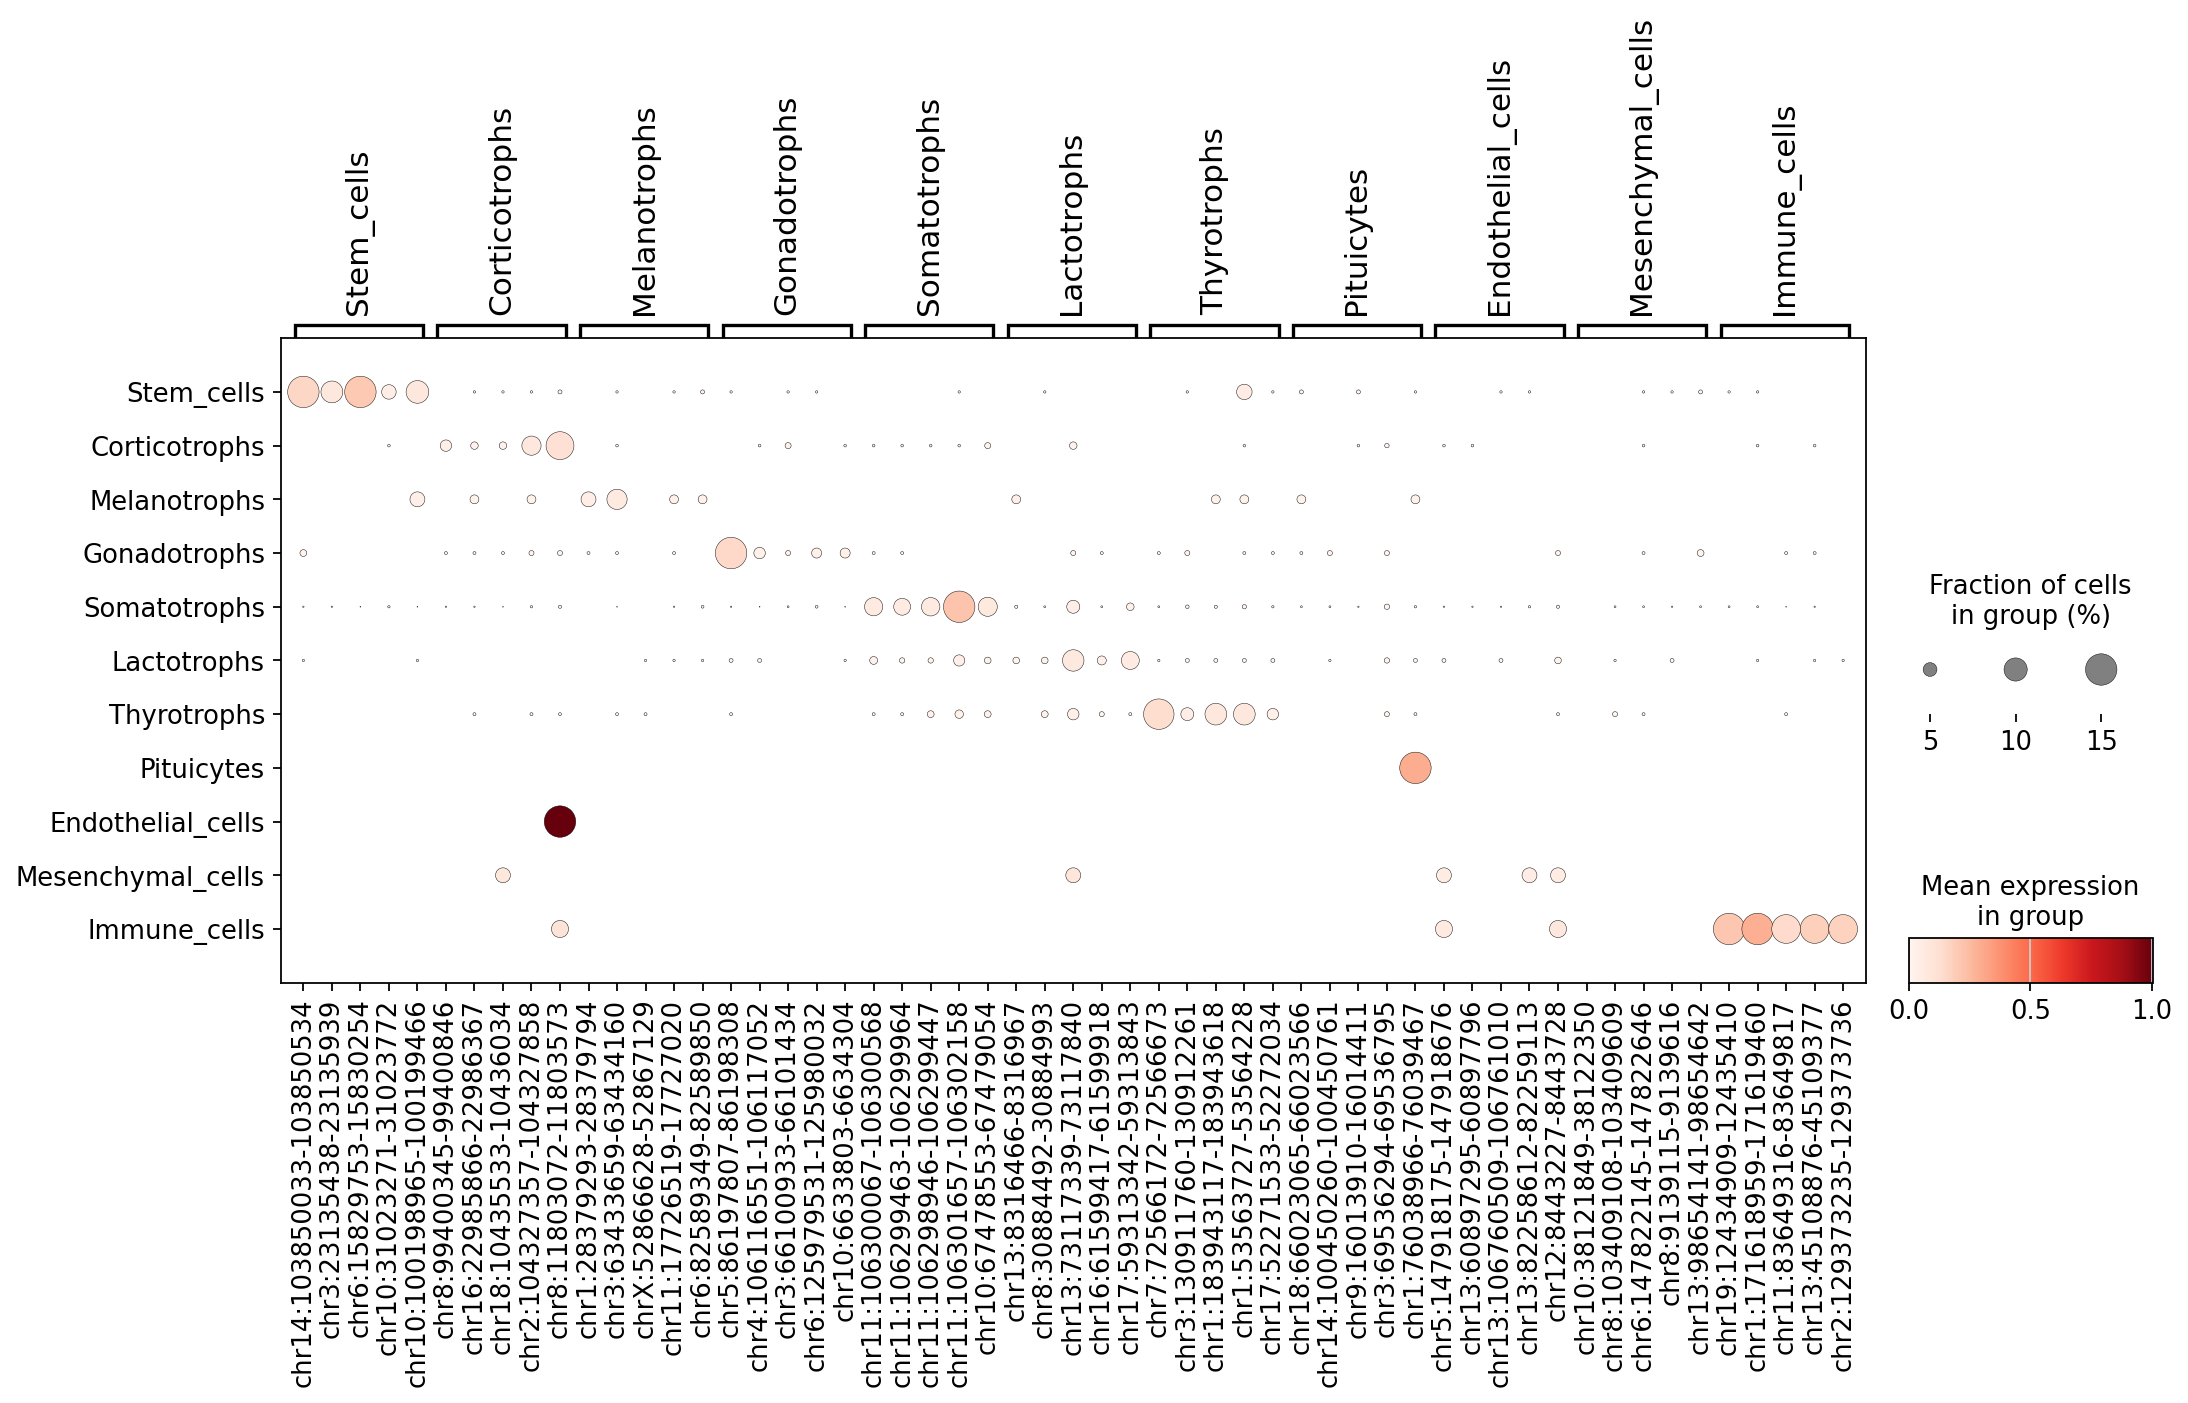

In [ ]:
# Filter the marker peaks to those included in the object
cell_type_order = ["Stem_cells", "Corticotrophs", "Melanotrophs", "Gonadotrophs", "Somatotrophs", "Lactotrophs", "Thyrotrophs", "Pituicytes", "Endothelial_cells", "Mesenchymal_cells", "Immune_cells"]

# Filter dictionary to only include cell types present, maintaining order
ct_markers_dict = {k: [x for x in v if x in peak_mat.var_names] for k, v in ct_markers_dict.items()}
ct_markers_dict = {
    k: ct_markers_dict[k] for k in cell_type_order
    if k in ct_markers_dict
}

# Cast the observation column to a Categorical type with the strict order
peak_mat.obs["cell_type_final"] = pd.Categorical(
    peak_mat.obs["cell_type_final"],
    categories=cell_type_order,
    ordered=True
)

sc.pl.dotplot(peak_mat, ct_markers_dict,  figsize=(15,5.3), groupby="cell_type_final",save="_dotplot_markers_atac.png",cmap="Reds", dot_max=0.15,use_raw=False) # Figure 4F
sc.pl.dotplot(peak_mat, ct_markers_dict,  figsize=(15,5.3), groupby="cell_type_final",save="_dotplot_markers_atac.svg",cmap="Reds",dot_max=0.15,use_raw=False)

### Print versions for reproducibility

In [ ]:
pip freeze

absl-py==1.4.0
accelerate==1.14.0
access==1.1.10.post3
affine==3.0.0
aiofiles==25.1.0
aiohappyeyeballs==2.7.1
aiohttp==3.14.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.1
altair==5.5.0
anndata==0.13.2
annotated-doc==0.0.5
annotated-types==0.8.0
antlr4-python3-runtime==4.9.3
anyio==4.14.2
anywidget==0.9.21
apsw==3.53.4.0
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array-api-compat==1.15.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.2
astropy-iers-data==0.2026.8.10.0.32.39
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioop-lts==0.2.2
audioread==3.1.0
Authlib==1.7.2
autograd==1.9.1
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b7
bigframes==2.42.0
bigquery-magics==0.14.0
bleach==6.4.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.11.0
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue=

# Instructions on running the notebook locally

## Setting up a conda environment, quick instructions

To create a conda environment, first ensure conda is correctly installed.

Instructions for installation are available at: https://docs.conda.io/projects/conda/en/latest/user-guide/install/index.html



```
%%bash
# Create environment
conda create -n protocol_env python=3.11 -y

# Register the environment as a reusable kernel for the workspace
conda run -n protocol_env pip install ipykernel
conda run -n protocol_env python -m ipykernel install --user --name protocol_env --display-name "Python (protocol_env)"
```



If working locally, the user is recommended to install these dependencies in a fresh conda environment using the following code:



```
%%bash
conda run -n protocol_env pip install -r requirements.txt
```



Then change the kernel to "Python (protocol_env)" before proceeding with further instructions.